# VinFast EV — EDA hỗ trợ quyết định mua xe tại Việt Nam

**Đối tượng:** người mua cá nhân. Mục tiêu: shortlist theo ngân sách, hiểu vùng giá rao,
so sánh mới/cũ có điều kiện, phát hiện tin cần xác minh, và mô phỏng chi phí vận hành.
Biểu đồ tiếng Anh, số liệu có đơn vị; diễn giải tiếng Việt.

Notebook 01 giữ lại EDA khám phá; notebook 02 này là bản phân tích có sàng lọc.
Không có chứng nhận giá giao dịch, tình trạng pin, khả năng bán nhanh hoặc thị phần toàn Việt Nam.
Không dùng free text để thay thế mã model; chỉ dùng để **gắn cờ mâu thuẫn**.
Ngày truy cập tham chiếu hãng không thay thế ngày hiệu lực chính sách hoặc ngày crawl lịch sử.

In [1]:
from pathlib import Path
import json, hashlib, re, unicodedata
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, MaxNLocator
from matplotlib.colors import LinearSegmentedColormap
from IPython.display import display, Markdown, Image

ROOT = Path.cwd()
if not (ROOT / 'data' / 'raw').exists(): ROOT = ROOT.parent
assert (ROOT / 'data' / 'raw').exists(), 'Run from repository or data visualization/'
FIG = ROOT / 'figures'
FIG.mkdir(exist_ok=True)
BLUE, TEAL, AMBER, INK, MUTED = '#2563EB', '#0D9488', '#D97706', '#172B4D', '#64748B'
plt.rcParams.update({'font.family':'DejaVu Sans', 'font.size':11,
    'axes.spines.top':False, 'axes.spines.right':False,
    'axes.spines.left':False, 'axes.spines.bottom':False,
    'figure.facecolor':'#F5F7FB', 'axes.facecolor':'#F5F7FB',
    'text.color':INK, 'axes.labelcolor':MUTED, 'xtick.color':MUTED, 'ytick.color':INK,
    'axes.titlesize':15, 'axes.titleweight':'bold', 'axes.titlelocation':'left',
    'axes.titlepad':20, 'axes.labelpad':12, 'xtick.major.size':0, 'ytick.major.size':0,
    'grid.color':'#DCE3EE', 'grid.linewidth':.7, 'axes.axisbelow':True,
    'legend.frameon':False, 'figure.dpi':120, 'savefig.dpi':180})
pd.set_option('display.max_columns', 20)
sources = sorted(p for d in ['raw','processed'] for p in (ROOT/'data'/d).glob('*') if p.is_file())
hashes = {str(p): hashlib.sha256(p.read_bytes()).hexdigest() for p in sources}
tables = {}
for p in sources:
    tables[p.name] = pd.DataFrame(json.loads(p.read_text(encoding='utf-8-sig'))) if p.suffix == '.json' else pd.read_csv(p)
saved = []
def chart_label(value):
    text=str(value).replace('VinFast ','')
    translations={'Dòng khác':'Other models','Thiếu tên mẫu':'Unknown model',
        'Mới':'New','Đã sử dụng':'Used','Không rõ':'Unknown',
        'Nhắc kèm/mua pin':'Battery included / purchased',
        'Nhắc thuê pin':'Battery rental',
        'Nhắc trả góp/trả trước':'Financing / down payment',
        'Nhắc khuyến mãi':'Promotions',
        'Nhắc đổi xe xăng':'ICE vehicle trade-in',
        'Nhắc bảo hành/hậu mãi':'Warranty / after-sales'}
    if text in translations: return translations[text]
    text=text.replace('TP Hồ Chí Minh','Ho Chi Minh City').replace('TP Hà Nội','Hanoi')
    if text.startswith('TP '): text=text[3:]+' City'
    return ''.join(c for c in unicodedata.normalize('NFD',text.replace('Đ','D').replace('đ','d')) if unicodedata.category(c)!='Mn')
def save(fig, name):
    fig.tight_layout(rect=(0,.055,1,.98),pad=1.7)
    fig.text(.025,.014,'VINFAST  /  CARS     •     Source: Cho Tot listing sample     •     Asking prices, not transaction prices',
             fontsize=8.5,color=MUTED)
    path = FIG / (name + '.png')
    fig.savefig(path, bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.close(fig)
    saved.append(path)
    display(Image(filename=str(path)))
def note(text): display(Markdown(text))
def barh(series, title, xlabel, name, color=BLUE):
    s = series.sort_index() if name.endswith('_year') else series.sort_values()
    fig, ax = plt.subplots(figsize=(12, max(5, len(s)*.43+2)))
    labels=[chart_label(x) for x in s.index]
    bars=ax.barh(labels, s.values, color=[color if v==s.max() else '#8FB2EB' for v in s],height=.6)
    percentage='(%)' in xlabel
    ax.bar_label(bars,labels=[f'{v:.1f}%' if percentage else f'{v:,.0f}' for v in s],padding=9,fontsize=11,color=INK)
    ax.set(title=title, xlabel=xlabel)
    if name.endswith('_year'): ax.set_ylabel('Manufacturing year (YYYY)')
    ax.set_xlim(0,max(s.max()*1.17,1))
    ax.xaxis.set_major_locator(MaxNLocator(nbins=5,integer=not percentage))
    ax.grid(axis='x')
    save(fig, name)

## A. Những cải thiện cần thiết và giá trị cho người mua

| Ưu tiên | Câu hỏi người mua | Cải thiện | Trạng thái bản này |
|---|---|---|---|
| P0 | Giá này có phải giá toàn xe? | Cách ly dịch vụ, nhãn xe xăng, giá không dương, nhãn nghi sai, giá trả trước | Bộ quy tắc công khai + hàng đợi kiểm tra |
| P0 | Dữ liệu còn mới không? | Snapshot có timestamp, kiểm tra trùng trang, tách cohort | Có 1 mẫu mới; chưa đủ lịch sử |
| P0 | Tôi có những lựa chọn nào? | Ma trận ngân sách × model × mới/cũ; tối thiểu số tin | Có, chỉ là shortlist để xác minh |
| P1 | Xe cũ rẻ hơn bao nhiêu? | Cùng model/năm/vùng, đếm người bán, bootstrap theo người bán | Có nhóm đủ mẫu; chưa kiểm soát phiên bản/pin |
| P1 | Tin giá thấp có đáng liên hệ? | Median/P25/P75 nhóm so sánh, n, số người bán, cờ nội dung | Có, không khẳng định món hời |
| P1 | So với xe mới chính hãng thì sao? | Giá theo phiên bản, tách ưu đãi có điều kiện, nguồn và ngày truy cập | 6 trang hãng, 12 cấu hình giá |
| P1 | Mua ở vùng khác có lợi? | So sánh trong nhóm; độ tập trung người bán; hỗ trợ mẫu | Có phần mô tả, không suy nhu cầu |
| P2 | Nuôi xe hết bao nhiêu? | Kịch bản km, giá điện, tổn hao, phí pin | Mô hình chi phí năng lượng, chưa phải TCO |
| P2 | Pin/bảo hành còn tốt không? | SOH, hợp đồng pin, lịch sử dịch vụ/VIN, ngày kích hoạt | Cần bổ sung dữ liệu xác minh |
| P2 | Xe nào dễ bán lại? | Snapshot đều đặn + xác nhận đã bán, kiểm duyệt mất dấu | Chưa thể kết luận DOM/doanh số |
| P2 | Sạc có thuận tiện không? | Trạm sạc theo tuyến, cổng hoạt động, khả năng sạc nhà | Chưa có dữ liệu địa điểm đáng tin cậy |

Không tạo điểm tổng hợp “đáng mua” khi trọng số ngân sách, chỗ ngồi, tuyến đi và sạc nhà chưa do người mua lựa chọn.

In [2]:
REFDIR=ROOT/'data/external/vinfast_20260913T022514Z'
SNAPDIR=ROOT/'data/raw/snapshots/20260913T022632Z'
manifest=json.loads((REFDIR/'manifest.json').read_text(encoding='utf-8'))
display(pd.DataFrame(manifest).reindex(columns=['source_key','status','retrieved_at_utc','record_count','source_url']))
snap=json.loads((SNAPDIR/'chotot_vinfast_snapshot.json').read_text(encoding='utf-8'))
fresh=pd.DataFrame([dict(r['ad'],crawl_date=r['crawl_date']) for r in snap]).drop_duplicates('list_id',keep='first')
legacy=tables['chotot_oto_raw.json'].query('carbrand == 80').drop_duplicates('list_id').copy()
legacy['crawl_date']=pd.NA
note(f'**Nguồn listing:** lịch sử {len(legacy)} ID VinFast (không biết crawl_date); mẫu mới {len(snap)} dòng/{fresh.list_id.nunique()} ID, có {len(set(fresh.list_id)-set(legacy.list_id))} ID chưa có trong lịch sử. Trang kế tiếp lặp ID nên dừng. Không gộp hai cohort để tính tỷ trọng, không coi mất dấu là đã bán.')
display(pd.DataFrame(json.loads((SNAPDIR/'manifest.json').read_text(encoding='utf-8'))['pages']))
# Manually checked variant ordering in the saved official HTML, numerical presence asserted.
prices={
 'VF3':[('Eco',270750000,285000000),('Plus',281200000,296000000)],
 'VF5':[('Plus',471200000,496000000)],
 'VF6':[('Eco',613700000,646000000),('Plus',664050000,699000000)],
 'VF7':[('Eco',703000000,740000000),('Plus',788500000,830000000),('Plus panoramic roof',807500000,850000000)],
 'VF8':[('Eco',853100000,898000000),('Plus',1025050000,1079000000)],
 'VF9':[('Eco',1280600000,1348000000),('Plus',1452550000,1529000000)]}
refs=[]
for family,variants in prices.items():
    info=next(x for x in manifest if x['source_key']==family)
    text=(REFDIR/(family+'.txt')).read_text(encoding='utf-8')
    for variant,promo,listed in variants:
        for amount in [promo,listed]: assert f'{amount:,}'.replace(',','.') in text
        refs.append(dict(family=family,variant=variant,promo_vnd=promo,displayed_regular_vnd=listed,
             source_url=info['source_url'],retrieved_at_utc=info['retrieved_at_utc'],
             effective_date=None,battery_inclusion='not independently verified',
             conditions='Displayed starting offer; eligibility, options and on-road fees require dealer confirmation',
             snapshot_sha256=info['sha256']))
refs=pd.DataFrame(refs)
OUT=ROOT/'data/processed/buyer_eda'; OUT.mkdir(parents=True,exist_ok=True)
refs.to_csv(OUT/'official_price_reference.csv',index=False,encoding='utf-8-sig')
display(refs[['family','variant','promo_vnd','displayed_regular_vnd','retrieved_at_utc','source_url']])
note('**Đọc tham chiếu:** giá ưu đãi là giá từ, có điều kiện; không phải giá lăn bánh hay mức áp dụng chắc chắn cho mọi khách. Không nối giá Eco vào tất cả tin của model rồi gọi phần chênh là tiết kiệm. Các giá snapshot hãng có thể khác thời điểm tin lịch sử. Benchmark cũ được tạo bằng số hardcode, không có ngày hiệu lực, nên không dùng.')

,source_key,status,retrieved_at_utc,record_count,source_url
0,VF3,200,2026-09-13T02:25:14.159319+00:00,NaN,https://shop.vinfastauto.com/vn_vi/dat-coc-xe-...
1,VF5,200,2026-09-13T02:25:16.358660+00:00,NaN,https://shop.vinfastauto.com/vn_vi/dat-coc-xe-...
2,VF6,200,2026-09-13T02:25:18.213345+00:00,NaN,https://shop.vinfastauto.com/vn_vi/dat-coc-xe-...
3,VF7,200,2026-09-13T02:25:20.181209+00:00,NaN,https://shop.vinfastauto.com/vn_vi/dat-coc-xe-...
4,VF8,200,2026-09-13T02:25:23.124824+00:00,NaN,https://shop.vinfastauto.com/vn_vi/dat-coc-xe-...
5,VF9,200,2026-09-13T02:25:24.860878+00:00,NaN,https://shop.vinfastauto.com/vn_vi/dat-coc-xe-...
6,warranty,403,2026-09-13T02:25:26.742594+00:00,NaN,https://vinfastauto.com/vn_vi/chinh-sach-bao-h...
7,chotot_probe,200,2026-09-13T02:25:27.998412+00:00,50.0,https://gateway.chotot.com/v1/public/ad-listin...
8,otodien_probe,200,2026-09-13T02:25:30.326734+00:00,NaN,https://otodien.vn/oto


**Nguồn listing:** lịch sử 950 ID VinFast (không biết crawl_date); mẫu mới 100 dòng/50 ID, có 27 ID chưa có trong lịch sử. Trang kế tiếp lặp ID nên dừng. Không gộp hai cohort để tính tỷ trọng, không coi mất dấu là đã bán.

,page,url,fetched_at_utc,status,rows,new_ids
0,0,https://gateway.chotot.com/v1/public/ad-listin...,2026-09-13T02:26:32.523060+00:00,200,50,50
1,1,https://gateway.chotot.com/v1/public/ad-listin...,2026-09-13T02:26:35.054884+00:00,200,50,0


,family,variant,promo_vnd,displayed_regular_vnd,retrieved_at_utc,source_url
0,VF3,Eco,270750000,285000000,2026-09-13T02:25:14.159319+00:00,https://shop.vinfastauto.com/vn_vi/dat-coc-xe-...
1,VF3,Plus,281200000,296000000,2026-09-13T02:25:14.159319+00:00,https://shop.vinfastauto.com/vn_vi/dat-coc-xe-...
2,VF5,Plus,471200000,496000000,2026-09-13T02:25:16.358660+00:00,https://shop.vinfastauto.com/vn_vi/dat-coc-xe-...
3,VF6,Eco,613700000,646000000,2026-09-13T02:25:18.213345+00:00,https://shop.vinfastauto.com/vn_vi/dat-coc-xe-...
4,VF6,Plus,664050000,699000000,2026-09-13T02:25:18.213345+00:00,https://shop.vinfastauto.com/vn_vi/dat-coc-xe-...
5,VF7,Eco,703000000,740000000,2026-09-13T02:25:20.181209+00:00,https://shop.vinfastauto.com/vn_vi/dat-coc-xe-...
6,VF7,Plus,788500000,830000000,2026-09-13T02:25:20.181209+00:00,https://shop.vinfastauto.com/vn_vi/dat-coc-xe-...
7,VF7,Plus panoramic roof,807500000,850000000,2026-09-13T02:25:20.181209+00:00,https://shop.vinfastauto.com/vn_vi/dat-coc-xe-...
8,VF8,Eco,853100000,898000000,2026-09-13T02:25:23.124824+00:00,https://shop.vinfastauto.com/vn_vi/dat-coc-xe-...
9,VF8,Plus,1025050000,1079000000,2026-09-13T02:25:23.124824+00:00,https://shop.vinfastauto.com/vn_vi/dat-coc-xe-...


**Đọc tham chiếu:** giá ưu đãi là giá từ, có điều kiện; không phải giá lăn bánh hay mức áp dụng chắc chắn cho mọi khách. Không nối giá Eco vào tất cả tin của model rồi gọi phần chênh là tiết kiệm. Các giá snapshot hãng có thể khác thời điểm tin lịch sử. Benchmark cũ được tạo bằng số hardcode, không có ngày hiệu lực, nên không dùng.

## B. Sàng lọc có thể kiểm tra lại

Loại khỏi **tập mô tả EV**: mã hãng không phải VinFast, model xe xăng theo danh mục hãng,
model chưa xác định, tiêu đề dịch vụ, mâu thuẫn model trong tiêu đề, năm ngoài khoảng nghiên cứu 2021–2026.
Tên xe vẫn lấy từ mã/nhãn cấu trúc, không sửa tên theo tiêu đề.

Tập **giá sàng lọc sơ bộ** còn cách ly giá không dương, giá dưới 100 triệu VND (ngưỡng nghiên cứu,
không phải giá tối thiểu thị trường), và giá có dấu hiệu trùng khoản trả trước trong tiêu đề.
Ngưỡng 100 triệu có thể loại xe hỏng/giá rẻ thật; luôn xem độ nhạy 50/100/150 triệu.
Không tự loại tất cả tin nhắc trả góp: giá niêm yết đầy đủ vẫn có thể đi kèm đề nghị vay.
Các cờ không chứng minh gian lận. Việc giữ lại cũng không chứng minh tin đã xác minh.

C:\Users\Admin\AppData\Local\Temp\ipykernel_24508\217537541.py:23: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  d['service_title']=title.str.contains(r'^(bao hiem|dich vu|phu kien|lop xe|sua chua)\b',regex=True)
C:\Users\Admin\AppData\Local\Temp\ipykernel_24508\217537541.py:23: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  d['service_title']=title.str.contains(r'^(bao hiem|dich vu|phu kien|lop xe|sua chua)\b',regex=True)


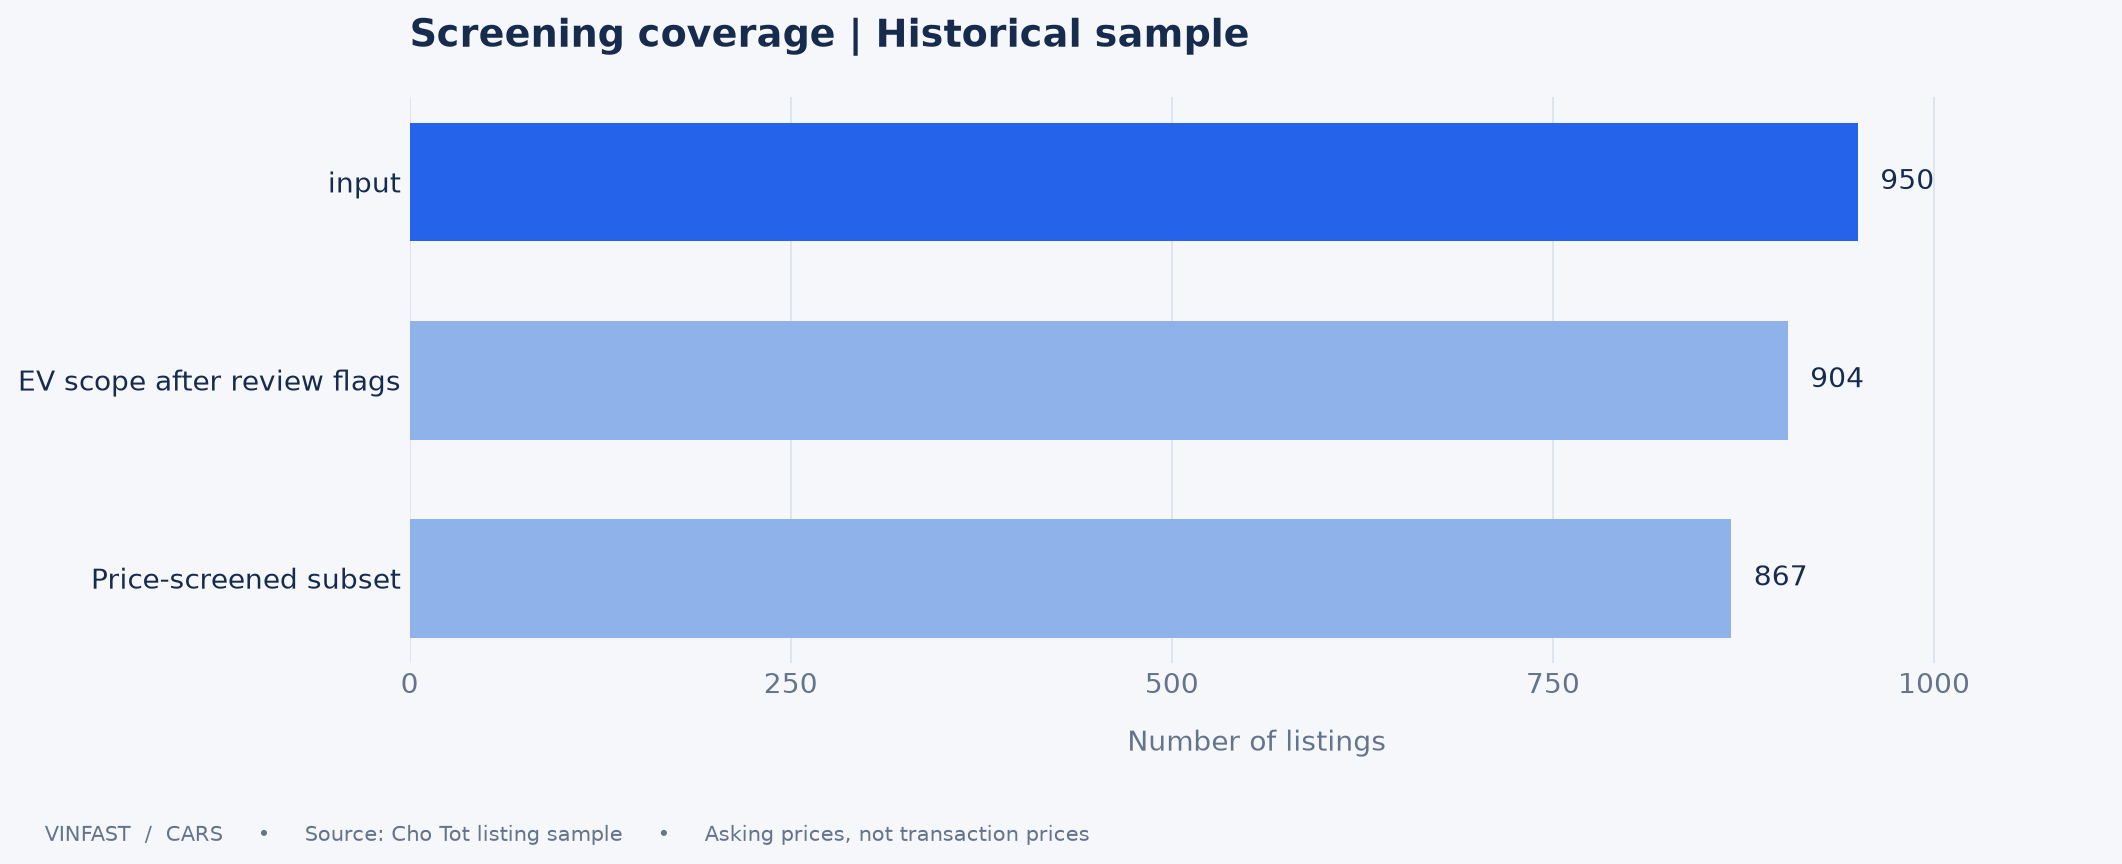

,flagged_listings_count
is_ice_label,3
unknown_ev_model,32
service_title,1
title_model_conflict,35
multiple_models_in_title,1
year_review,1
nonpositive_price,2
low_price_review,32
upfront_price_match,17


,list_id,subject,model_source,price_vnd,review_reasons
32,134575209,VF5 NHẬN XE CHỈ TỪ 65tr - HỖ TRỢ NỢ XẤU,VF5,77000000,low_price_review
40,133375442,VF2 2026-CỌC TIÊN PHONG-ƯU ĐÃI NGAY 8 TRIỆU,Dòng khác,188000000,unknown_ev_model; title_model_conflict
41,134616364,VinFast VF8 Đen Giao Sớm - Trả trước 158tr,VF8,158000000,upfront_price_match
63,134630884,Xe điện VinFast VF2 Trắng,Dòng khác,188000000,unknown_ev_model; title_model_conflict
71,134347211,VF7 2026 Pin chạy 450km - trả trước 80tr,VF7,80000000,low_price_review; upfront_price_match
73,134327657,"VinFast VF9 Plus 2026 - 7c, chỉ cần 229tr",VF9,229000000,upfront_price_match
77,134362470,VinFast VF3 Plus 2026 Xám trả trước 33tr,VF3,33000000,low_price_review; upfront_price_match
105,133430676,VinFast MPV 7|Giảm hơn 100 Triệu|Từ 10 Triệu/t...,Dòng khác,650000000,unknown_ev_model; title_model_conflict
110,134627226,VinFast VF MPV 7,Dòng khác,750000000,unknown_ev_model; title_model_conflict
122,134610346,"VINFAST VF2 – XE ĐIỆN MINI NHỎ GỌN, LINH HOẠT",Dòng khác,180000000,unknown_ev_model; title_model_conflict


,cohort,input_listings,price_screened_listings
0,Historical,950,867
1,Fresh,50,48


**Kết quả:** 867/950 tin lịch sử vào tập giá sàng lọc sơ bộ. 83 tin nằm trong hàng đợi kiểm tra. Không gán ngày crawl mới cho các tin lịch sử. File xuất giữ hai cohort riêng; mọi phân tích bên dưới dùng historical trừ khi ghi rõ.

,list_id,family,crawl_date,price_vnd_fresh,price_vnd_historical,observed_price_difference_vnd
12,134326729,VF3,2026-09-13T02:26:32.523060+00:00,249000000,258000000,-9000000


**Kiểm tra cập nhật:** 23 ID gặp lại, 1 ID có giá khác bản lịch sử. Đây là chênh lệch hai bản quan sát; chưa có thời điểm crawl cũ nên không tính tốc độ giảm giá hoặc DOM.

In [3]:
def norm(x):
    return re.sub(r'\s+',' ',''.join(c for c in unicodedata.normalize('NFD',str(x).lower().replace('đ','d')) if unicodedata.category(c)!='Mn')).strip()
family_map={'VF5 Plus':'VF5','VF8 Lux':'VF8','VFe34':'VFe34','MPV 7':'MPV7'}
ev_labels={'VF2','VF3','VF5','VF5 Plus','VF6','VF7','VF8','VF8 Lux','VF9','VFe34','Limo Green','Minio Green','Herio Green','Nerio Green','EC VAN','MPV 7'}
ice_labels={'Fadil','Lux SA2.0','Lux A2.0','President'}
family_patterns={**{f'VF{i}':rf'\bvf\s*{i}\b' for i in [2,3,5,6,7,8,9]},
 'VFe34':r'\bvf\s*e\s*34\b','MPV7':r'\bmpv\s*7\b','Limo Green':r'\blimo\s*green\b',
 'Minio Green':r'\bminio\b','Herio Green':r'\bherio\b','Nerio Green':r'\bnerio\b','EC VAN':r'\bec\s*van\b'}
def screen(raw,cohort):
    assert raw.carbrand.eq(80).all(), 'Unexpected brand in cohort'
    d=raw.copy(); d['cohort']=cohort
    d['model_source']=d.carmodel_name
    d['family']=d.model_source.map(lambda x:family_map.get(x,x))
    d['condition']=d.condition_ad_name.map({'Mới':'New','Đã sử dụng':'Used'}).fillna('Unknown')
    d['region']=d.region_name_v3.fillna(d.region_name).map(chart_label)
    d['year']=pd.to_numeric(d.mfdate,errors='coerce')
    d['price_vnd']=pd.to_numeric(d.price,errors='coerce'); d['price_million']=d.price_vnd/1e6
    d['odo_km']=pd.to_numeric(d.get('mileage_v2',pd.Series(index=d.index,dtype=float)),errors='coerce')
    d['seller_key']=d.account_id.fillna(d.list_id).astype(str)
    title=d.subject.fillna('').map(norm); body=d.body.fillna('').map(norm)
    d['is_ice_label']=d.model_source.isin(ice_labels)
    d['unknown_ev_model']=~d.model_source.isin(ev_labels|ice_labels)
    d['service_title']=title.str.contains(r'^(bao hiem|dich vu|phu kien|lop xe|sua chua)\b',regex=True)
    mentions=title.map(lambda t:{f for f,pat in family_patterns.items() if re.search(pat,t)})
    d['title_model_conflict']=[bool(m) and f not in m for f,m in zip(d.family,mentions)]
    d['multiple_models_in_title']=mentions.map(len).gt(1)
    d['year_review']=~d.year.between(2021,2026)
    d['nonpositive_price']=~d.price_vnd.gt(0)
    d['low_price_review']=d.price_vnd.lt(100e6)
    amounts=title.map(lambda t:[float(v.replace(',','.'))*1e6 for v in re.findall(r'(?:tra truoc|chi can|chi tu|tu)\s*(\d+(?:[.,]\d+)?)\s*(?:trieu|tr)\b',t)])
    d['upfront_price_match']=[any(abs(p-a)<=max(1e6,.05*a) for a in vals) for p,vals in zip(d.price_vnd,amounts)]
    text=title+' '+body
    d['financing_mention']=text.str.contains(r'\b(?:tra gop|tra truoc|lai suat)\b')
    d['promo_mention']=text.str.contains(r'\b(?:uu dai|khuyen mai|giam gia|voucher|ctkm)\b')
    d['battery_rental_mention']=text.str.contains(r'\b(?:thue pin|pin thue)\b')
    d['battery_purchase_mention']=text.str.contains(r'\b(?:mua pin|pin mua|kem pin|mua dut pin)\b')
    d['battery_topic']=np.select([d.battery_rental_mention & d.battery_purchase_mention,d.battery_rental_mention,d.battery_purchase_mention],['Both mentioned','Rental mentioned','Purchase mentioned'],default='Not mentioned')
    scope=['is_ice_label','unknown_ev_model','service_title','title_model_conflict','multiple_models_in_title','year_review']
    d['scope_eligible']=~d[scope].any(axis=1)
    d['price_eligible']=d.scope_eligible & ~d[['nonpositive_price','low_price_review','upfront_price_match']].any(axis=1)
    reasons=scope+['nonpositive_price','low_price_review','upfront_price_match']
    d['review_reasons']=d[reasons].apply(lambda r:'; '.join(k for k,v in r.items() if v),axis=1)
    d['is_trackable']=d.list_id.notna() & d.crawl_date.notna()
    return d
historical=screen(legacy,'legacy_unknown_crawl_date'); recent=screen(fresh,'fresh_timestamped')
assert not historical.loc[historical.list_id.eq(134511760),'price_eligible'].any(), 'Insurance ad must be excluded'
assert not historical.loc[historical.list_id.eq(133717684),'price_eligible'].any(), 'Model conflict must be reviewed'
exportcols=['list_id','cohort','crawl_date','is_trackable','model_source','family','condition','year','odo_km','region','seller_key','price_vnd','scope_eligible','price_eligible','review_reasons','battery_topic','financing_mention','promo_mention','subject']
pd.concat([historical,recent])[exportcols].to_csv(OUT/'screened_listings.csv',index=False,encoding='utf-8-sig')
historical.loc[~historical.price_eligible,exportcols].to_csv(OUT/'manual_review_queue.csv',index=False,encoding='utf-8-sig')
assert historical.list_id.is_unique and recent.list_id.is_unique
counts=pd.Series({'VinFast input':len(historical),'EV scope after review flags':historical.scope_eligible.sum(),'Price-screened subset':historical.price_eligible.sum()})
barh(counts,'Screening coverage | Historical sample','Number of listings','buyer_01_screening')
reasons=['is_ice_label','unknown_ev_model','service_title','title_model_conflict','multiple_models_in_title','year_review','nonpositive_price','low_price_review','upfront_price_match']
display(historical[reasons].sum().to_frame('flagged_listings_count'))
display(historical.loc[~historical.price_eligible,['list_id','subject','model_source','price_vnd','review_reasons']].head(20))
clean=historical.loc[historical.price_eligible].copy()
display(pd.DataFrame({'cohort':['Historical','Fresh'],'input_listings':[len(historical),len(recent)],'price_screened_listings':[len(clean),int(recent.price_eligible.sum())]}))
note(f'**Kết quả:** {len(clean)}/{len(historical)} tin lịch sử vào tập giá sàng lọc sơ bộ. {len(historical)-len(clean)} tin nằm trong hàng đợi kiểm tra. Không gán ngày crawl mới cho các tin lịch sử. File xuất giữ hai cohort riêng; mọi phân tích bên dưới dùng historical trừ khi ghi rõ.')
observed=recent[['list_id','family','crawl_date','price_vnd']].merge(historical[['list_id','price_vnd']],on='list_id',suffixes=('_fresh','_historical'),validate='one_to_one')
observed['observed_price_difference_vnd']=observed.price_vnd_fresh-observed.price_vnd_historical
observed.to_csv(OUT/'observed_price_changes.csv',index=False,encoding='utf-8-sig')
display(observed[observed.observed_price_difference_vnd.ne(0)])
note(f'**Kiểm tra cập nhật:** {len(observed)} ID gặp lại, {(observed.observed_price_difference_vnd!=0).sum()} ID có giá khác bản lịch sử. Đây là chênh lệch hai bản quan sát; chưa có thời điểm crawl cũ nên không tính tốc độ giảm giá hoặc DOM.')

## C. Với ngân sách của tôi, những model nào có đủ lựa chọn?

Ngân sách ở đây là **giá mua xe**, chưa gồm chi phí lăn bánh, vay hoặc bảo hiểm.
Ma trận đếm tin có giá không vượt ngân sách, không phải đếm xe chắc chắn mua được.
Tách mới/cũ và chỉ hiển thị nhóm có ít nhất 10 tin sàng lọc. Không dùng giá rẻ nhất làm khuyến nghị.

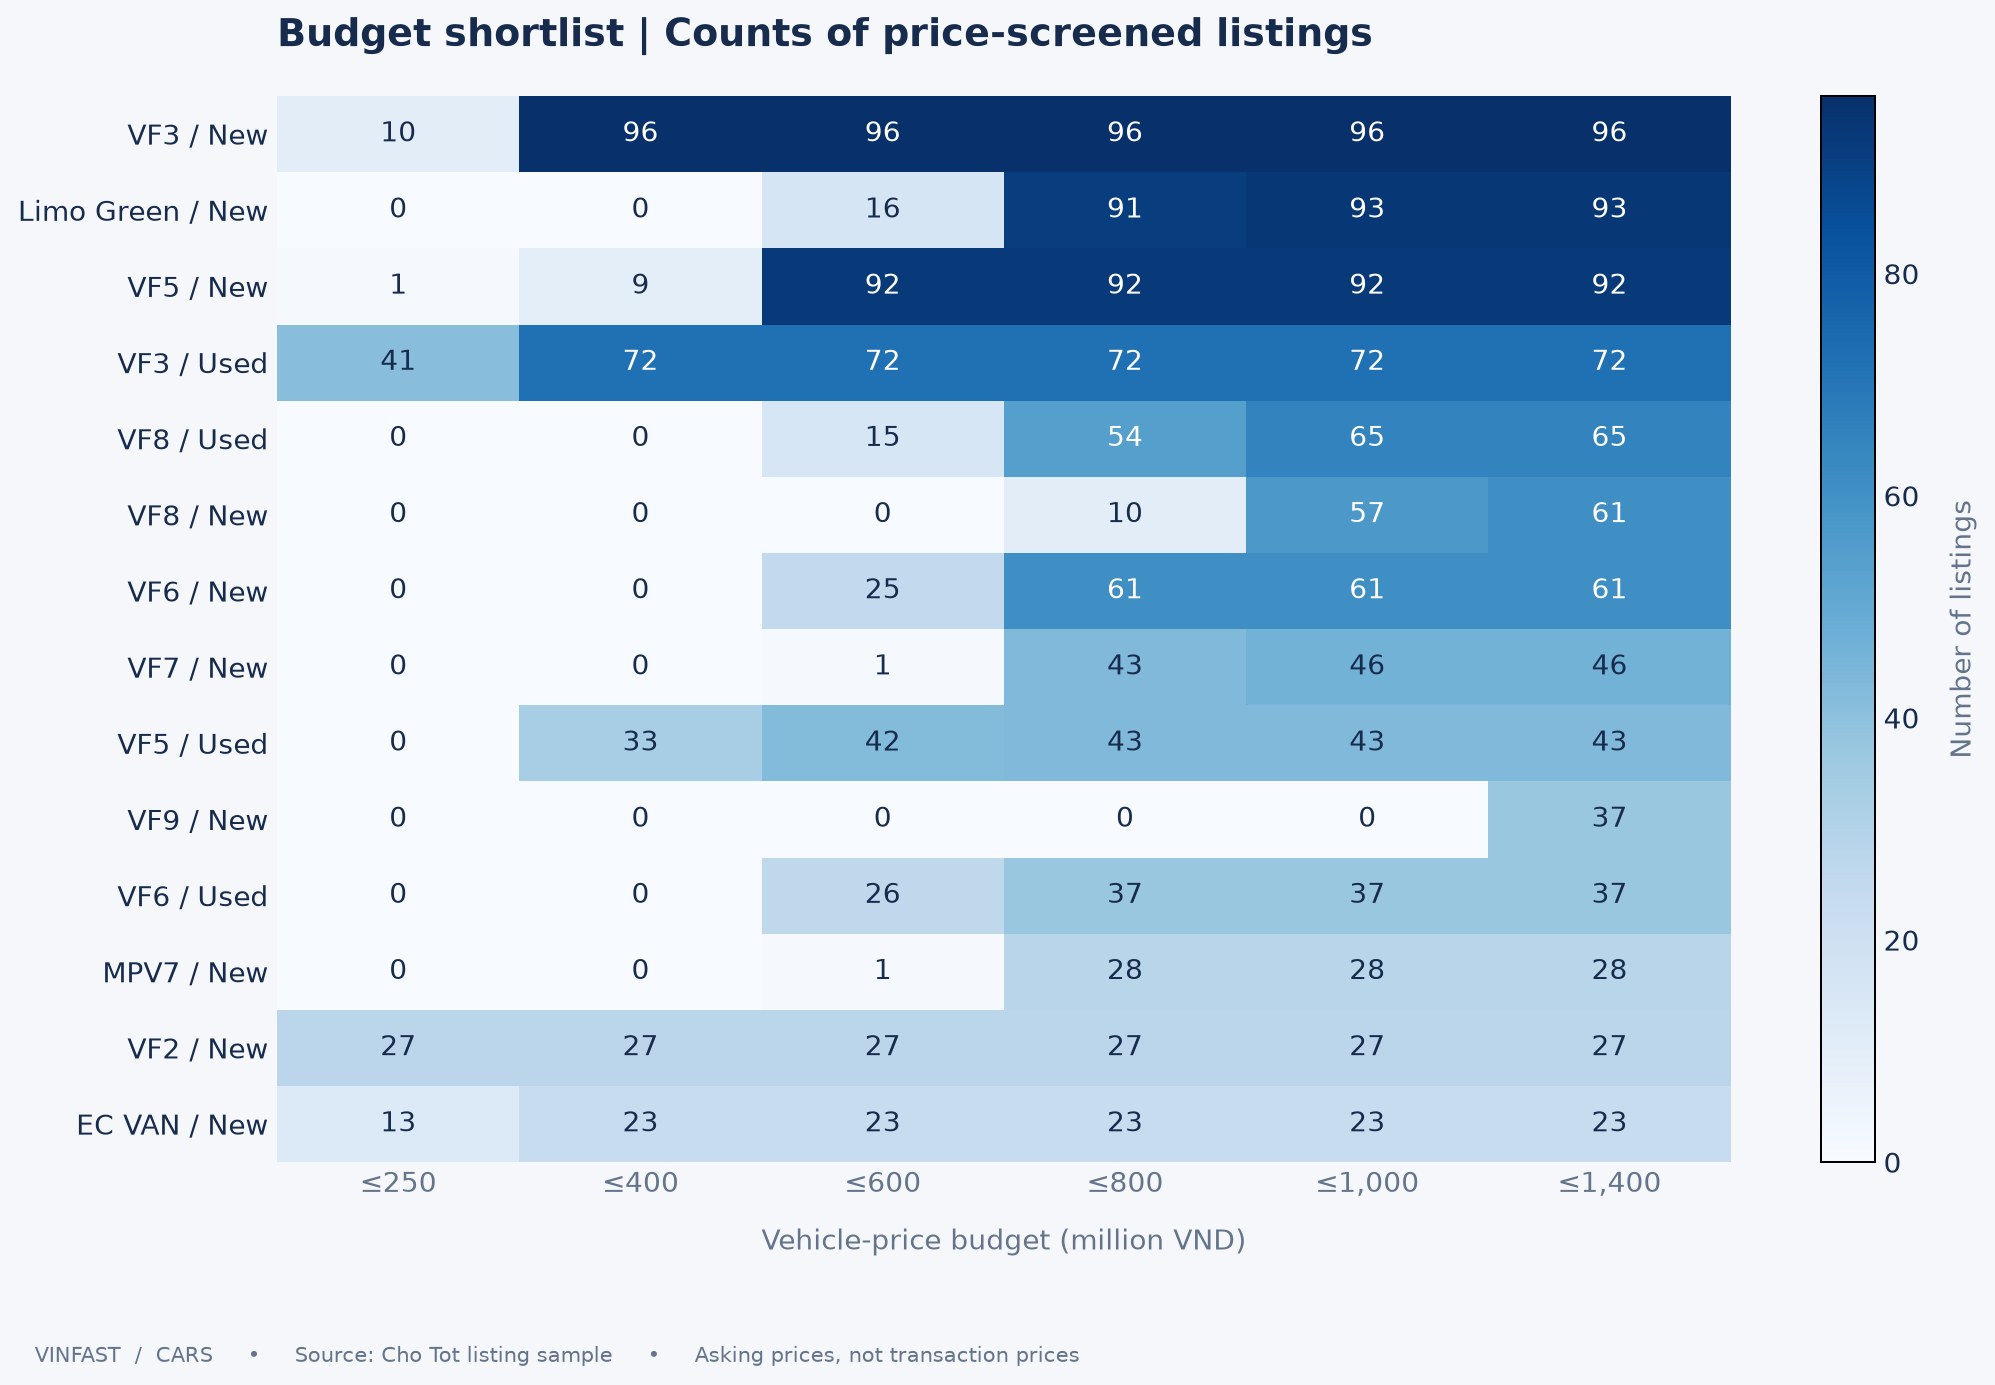

,250 million VND budget,400 million VND budget,600 million VND budget,800 million VND budget,1000 million VND budget,1400 million VND budget
Model / condition,,,,,,
VF3 / New,10,96,96,96,96,96
Limo Green / New,0,0,16,91,93,93
VF5 / New,1,9,92,92,92,92
VF3 / Used,41,72,72,72,72,72
VF8 / Used,0,0,15,54,65,65
VF8 / New,0,0,0,10,57,61
VF6 / New,0,0,25,61,61,61
VF7 / New,0,0,1,43,46,46
VF5 / Used,0,33,42,43,43,43


listings  median      p25      p75  distinct_sellers
family      condition                                                      
EC VAN      New              23   248.0   248.00   268.00                21
            Used              1   306.0   306.00   306.00                 1
Herio Green New               5   397.0   325.00   420.00                 5
            Used              1   359.0   359.00   359.00                 1
Limo Green  New              93   644.0   629.00   664.00                62
            Used             21   615.0   595.00   625.00                18
MPV7        New              28   693.0   650.00   707.50                27
            Used              3   640.0   637.50   645.00                 3
Minio Green New               5   180.0   175.00   184.00                 5
            Used              4   188.0   183.00   188.00                 4
Nerio Green Used              1   450.0   450.00   450.00                 1
VF2         New              27   180.0   179.78   180.00                27
VF3         New              96   278.0   270.94   279.00                63
            Used             72   248.0   212.25   265.00                53
VF5         New              92   438.0   425.00   471.00                64
            Used             43   370.0   352.50   399.00                41
VF6         New              61   615.0   586.00   646.00                49
            Used             37   565.0   536.00   608.00                26
VF7         New              46   740.0   700.75   740.00                24
            Used             17   690.0   639.00   739.00                15
VF8         New              61   848.0   840.00   898.00                30
            Used             65   678.0   610.00   745.00                36
VF9         New              40  1348.0  1248.75  1348.00                14
            Used             16  1160.0  1140.00  1191.25                10
VFe34       Used              9   350.0   350.00   369.00                 9

**Ví dụ ngân sách 250 triệu VND, xe cũ:** nhóm nhiều tin phù hợp giá nhất là VF3 (41 tin); chỉ xét giá xe, cần cộng phí và kiểm tra điều kiện pin.

**Ví dụ ngân sách 400 triệu VND, xe cũ:** nhóm nhiều tin phù hợp giá nhất là VF3 (72 tin); chỉ xét giá xe, cần cộng phí và kiểm tra điều kiện pin.

**Ví dụ ngân sách 600 triệu VND, xe cũ:** nhóm nhiều tin phù hợp giá nhất là VF3 (72 tin); chỉ xét giá xe, cần cộng phí và kiểm tra điều kiện pin.

**Cách dùng:** chọn ngân sách, chọn mới/cũ rồi ưu tiên nhóm có đủ tin và người bán độc lập. So sánh bảng P25–P75 thay vì chọn giá nhỏ nhất. “Có 20 tin dưới ngân sách” không có nghĩa 20 chiếc khác nhau hoặc đủ điều kiện pin/phí cho người mua.

In [4]:
budgets=[250,400,600,800,1000,1400]
groups=clean.groupby(['family','condition']).size().loc[lambda s:s>=10].sort_values(ascending=False).head(14).index
matrix=pd.DataFrame([[int(((clean.family==f)&(clean.condition==c)&(clean.price_million<=b)).sum()) for b in budgets] for f,c in groups],index=[f'{f} / {c}' for f,c in groups],columns=budgets)
fig,ax=plt.subplots(figsize=(12,8))
im=ax.imshow(matrix,cmap='Blues',aspect='auto')
ax.set_xticks(range(len(budgets)),[f'≤{b:,}' for b in budgets]); ax.set_yticks(range(len(matrix)),matrix.index)
for i in range(len(matrix)):
    for j in range(len(budgets)):
        val=matrix.iloc[i,j]; ax.text(j,i,str(val),ha='center',va='center',color='white' if val>matrix.values.max()/2 else INK)
ax.set(title='Budget shortlist | Counts of price-screened listings',xlabel='Vehicle-price budget (million VND)')
fig.colorbar(im,ax=ax,label='Number of listings'); save(fig,'buyer_02_budget')
display(matrix.rename_axis('Model / condition').add_suffix(' million VND budget'))
summary=clean.groupby(['family','condition']).price_million.agg(listings='size',median='median',p25=lambda x:x.quantile(.25),p75=lambda x:x.quantile(.75))
summary=summary.join(clean.groupby(['family','condition']).seller_key.nunique().rename('distinct_sellers'))
summary.to_csv(OUT/'buyer_price_summary_million_vnd.csv',encoding='utf-8-sig')
display(summary.round(2))
for budget in [250,400,600]:
    choices=clean[(clean.condition=='Used') & clean.price_million.le(budget)].family.value_counts()
    if len(choices): note(f'**Ví dụ ngân sách {budget} triệu VND, xe cũ:** nhóm nhiều tin phù hợp giá nhất là {choices.index[0]} ({choices.iloc[0]} tin); chỉ xét giá xe, cần cộng phí và kiểm tra điều kiện pin.')
note('**Cách dùng:** chọn ngân sách, chọn mới/cũ rồi ưu tiên nhóm có đủ tin và người bán độc lập. So sánh bảng P25–P75 thay vì chọn giá nhỏ nhất. “Có 20 tin dưới ngân sách” không có nghĩa 20 chiếc khác nhau hoặc đủ điều kiện pin/phí cho người mua.')

## D. Mua cũ so với mua mới: so sánh có điều kiện

Chỉ so sánh cùng family (gộp VF5/VF5 Plus có công bố), năm sản xuất và vùng. Mỗi phía cần
ít nhất 8 tin và 3 người bán. Bootstrap **theo cụm người bán**, 300 lần, seed cố định;
trong mỗi lần lấy lại các cụm người bán, giữ các tin của cụm. Khoảng 90% thể hiện độ biến động
trong mẫu, không sửa sai lệch chọn mẫu hoặc nhãn sai.
Chênh lệch = median(new) − median(used), không phải khấu hao hay tác động nhân quả.

,family,year,region,new_n,used_n,new_sellers,used_sellers,new_median,used_median,gap_million_vnd,low,high
0,VF6,2025,Ho Chi Minh City,9,11,8,6,583.0,555.0,28.0,7.5,64.0


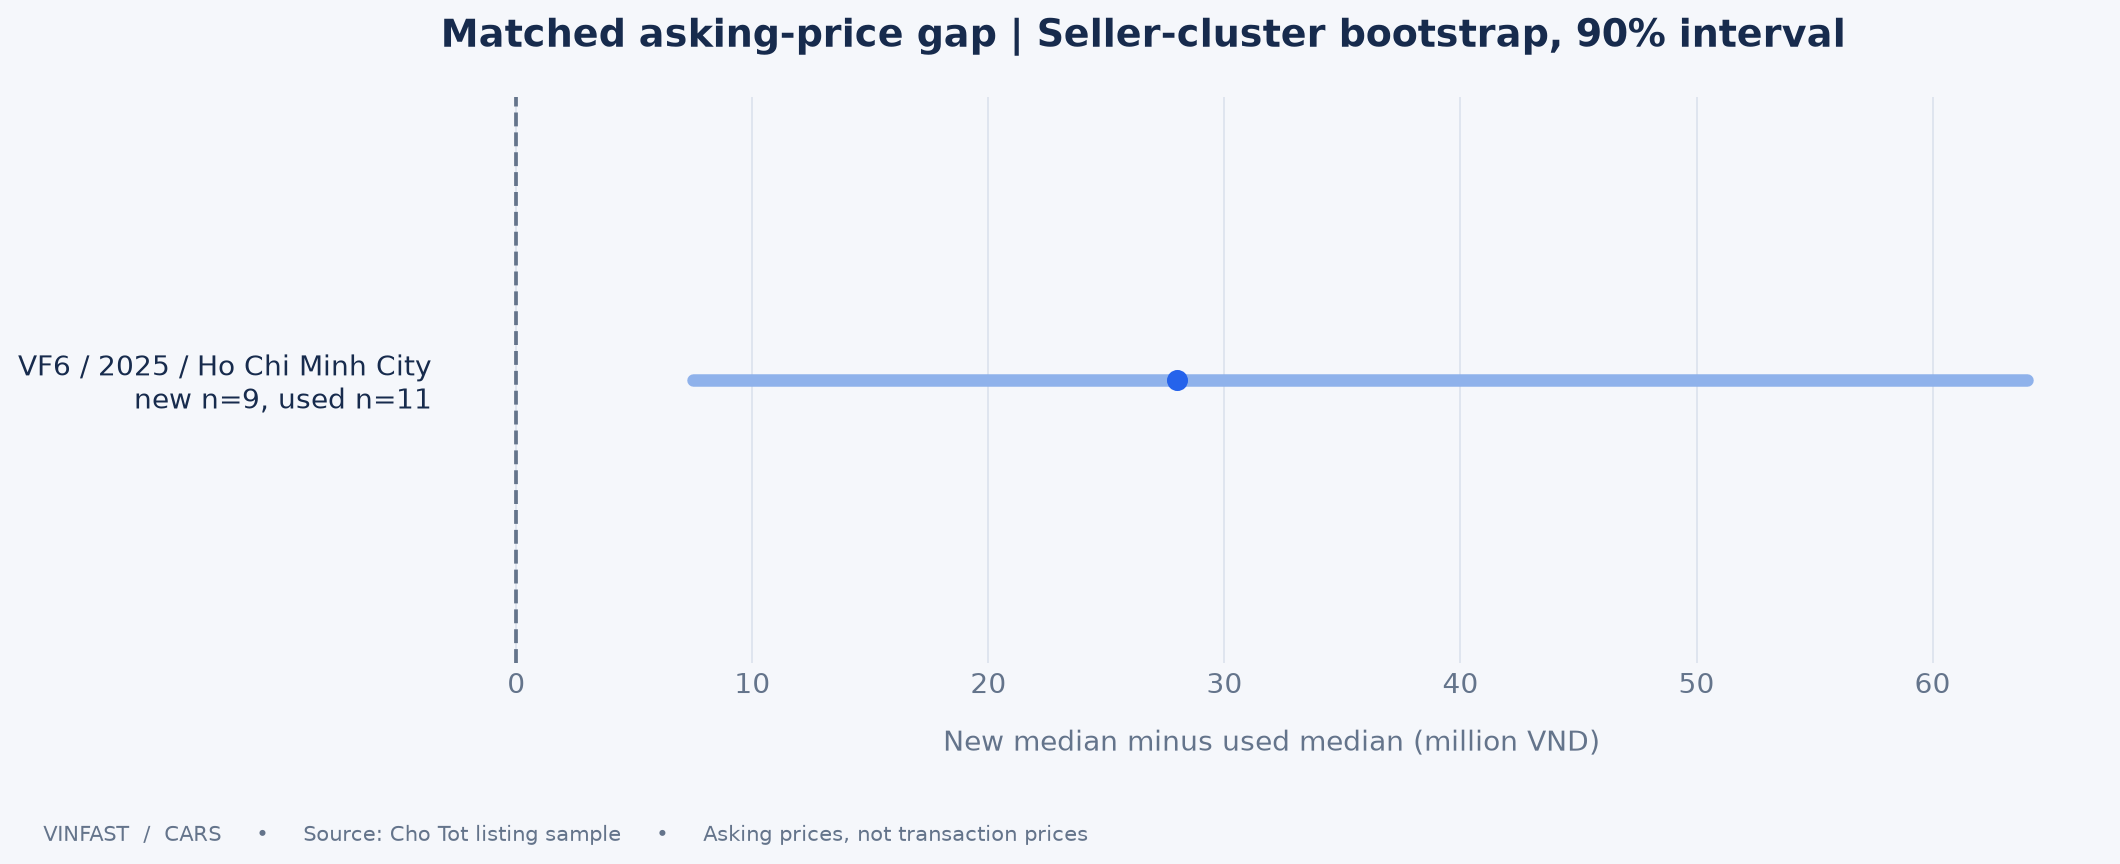

**Kết quả có hỗ trợ mẫu:** VF6, năm 2025, Ho Chi Minh City: median mới 583.0 triệu VND (9 tin), cũ 555.0 triệu VND (11 tin). Chênh 28.0 triệu; khoảng bootstrap 90% 7.5–64.0 triệu VND. Không dùng chênh lệch này như khấu hao của một xe.

**Giới hạn quan trọng:** cùng model–năm–vùng vẫn có thể khác phiên bản, hợp đồng pin, ODO và lịch sử sử dụng. Nếu khoảng cắt 0 hoặc mẫu nhỏ, không xếp hạng “tiết kiệm” chắc chắn. Tin mới/cũ là nhãn người đăng; chưa là điều kiện đã kiểm định.

,listings,reported,missing_pct
condition,,,
New,577,3,99.48
Used,290,290,0.00


**Phát hiện về độ thiếu:** cần đọc ODO theo tình trạng xe. Tin mới thường không khai ODO; dùng tỷ lệ thiếu toàn mẫu để loại bỏ phân tích xe cũ sẽ bỏ phí dữ liệu. ODO có khai báo vẫn là tự báo cáo, chưa đối chiếu lịch sử dịch vụ.

,listings,median_million_vnd
odo_band_km,,
"0–10,000",20,260.500000
"10,001–30,000",19,255.000000
"30,001–60,000",5,229.000000
">60,000",2,226.111111


,listings,median_million_vnd
odo_band_km,,
"0–10,000",1,630.0
"10,001–30,000",2,715.0
"30,001–60,000",20,672.5
">60,000",12,567.5


,listings,median_million_vnd
odo_band_km,,
"0–10,000",7,219.0
"10,001–30,000",14,198.0


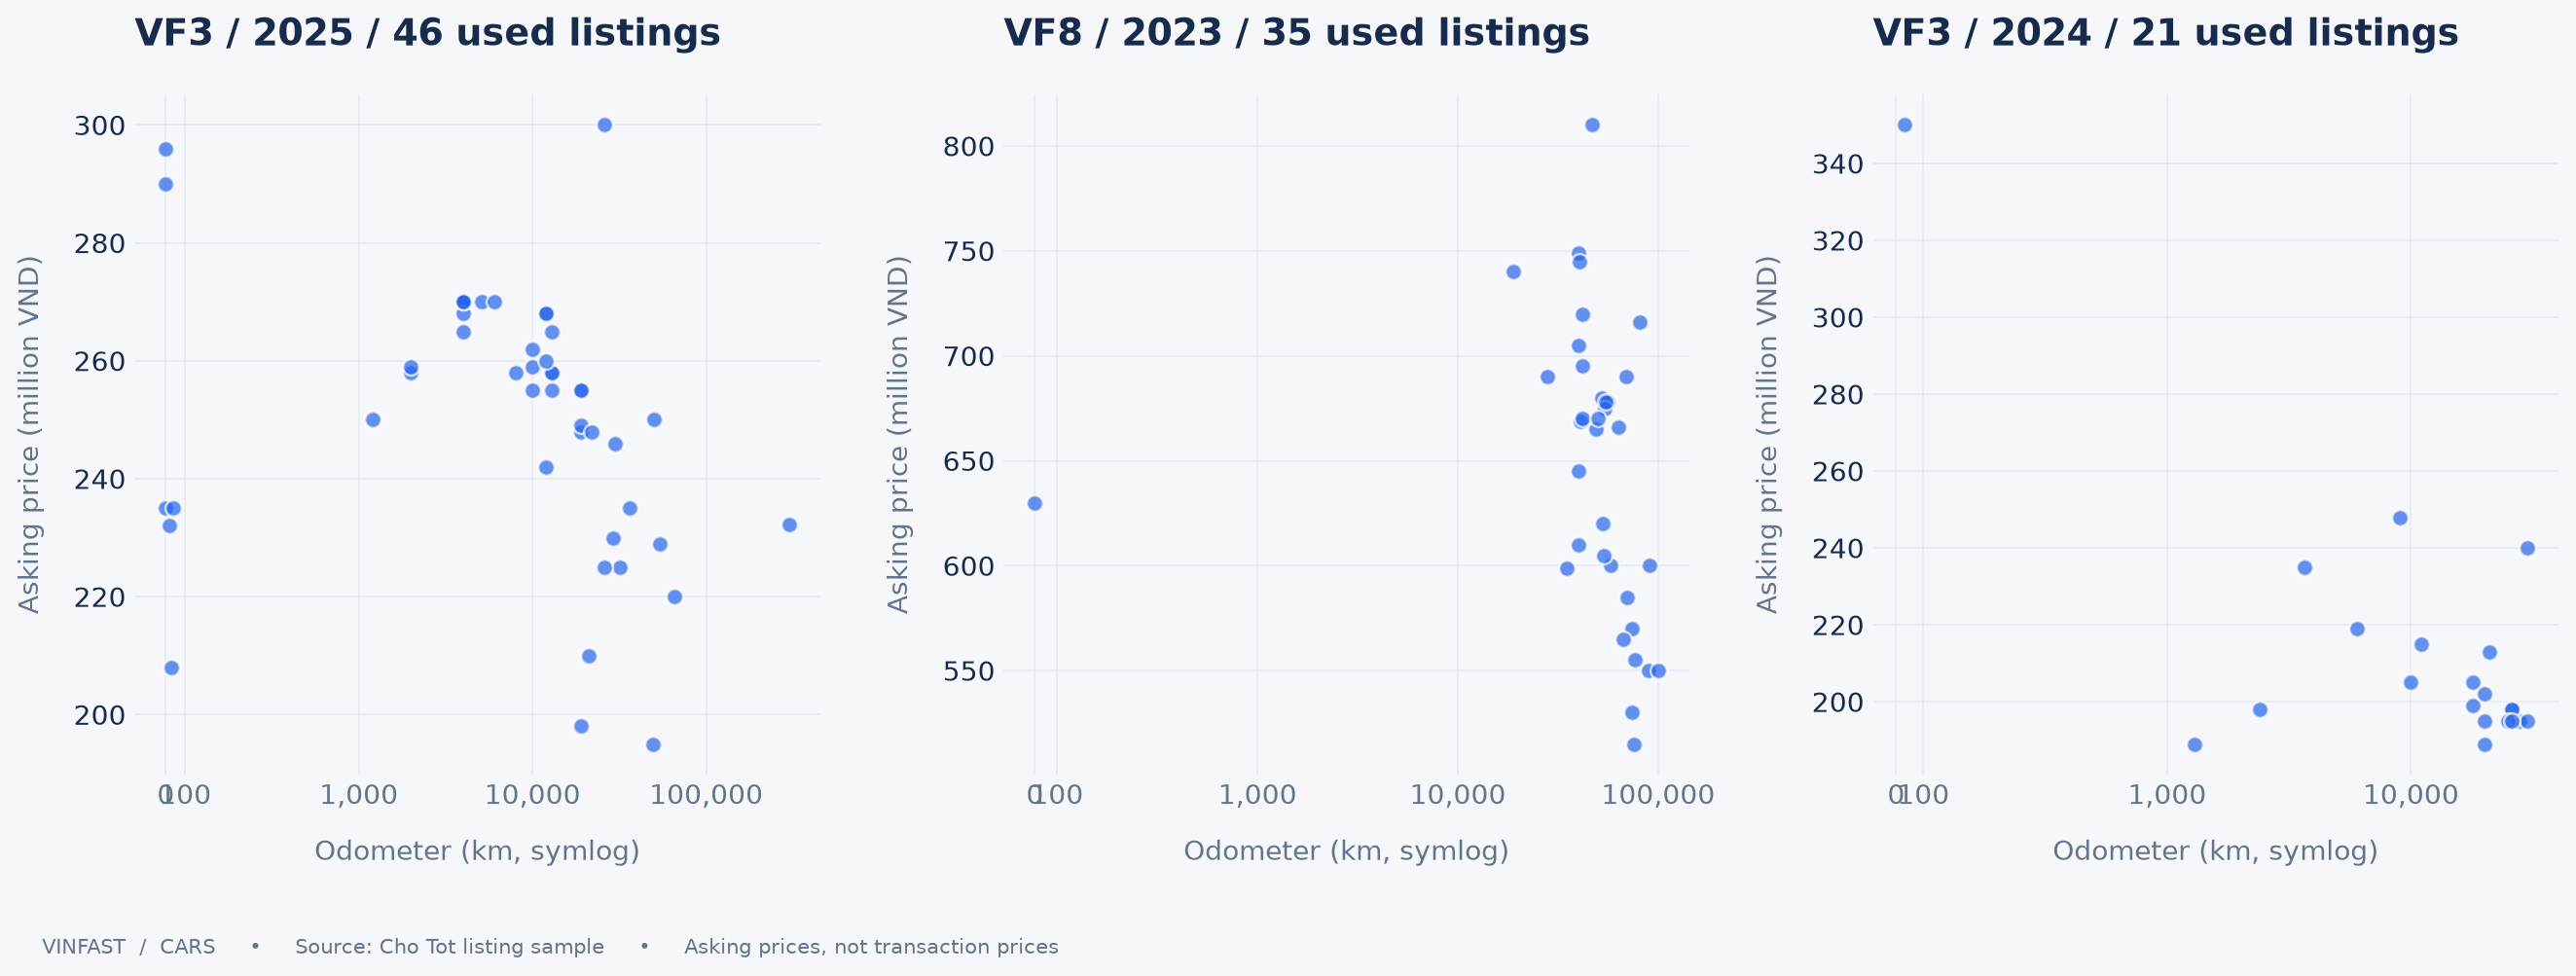

**Giá–ODO xe cũ:** mỗi ô giữ cùng model và năm sản xuất, dùng thang symlog để không che giá trị lớn. Bảng theo dải km giúp đọc median nhưng không có kiểm soát phiên bản/vùng/pin. Không vẽ đường khấu hao từ vài điểm hoặc coi ODO lớn là gian lận.

In [5]:
rng=np.random.default_rng(42)
def cluster_medians(g,reps=300):
    clusters=[x.price_million.to_numpy() for _,x in g.groupby('seller_key')]
    return np.array([np.median(np.concatenate([clusters[i] for i in rng.integers(0,len(clusters),len(clusters))])) for _ in range(reps)])
matched=[]
for (f,y,r),g in clean.groupby(['family','year','region']):
    a=g[g.condition=='New']; b=g[g.condition=='Used']
    if min(len(a),len(b))<8 or min(a.seller_key.nunique(),b.seller_key.nunique())<3: continue
    delta=cluster_medians(a)-cluster_medians(b)
    matched.append(dict(family=f,year=int(y),region=r,new_n=len(a),used_n=len(b),new_sellers=a.seller_key.nunique(),used_sellers=b.seller_key.nunique(),new_median=a.price_million.median(),used_median=b.price_million.median(),gap_million_vnd=a.price_million.median()-b.price_million.median(),low=np.quantile(delta,.05),high=np.quantile(delta,.95)))
matched=pd.DataFrame(matched)
display(matched.round(2))
if not matched.empty:
    matched.to_csv(OUT/'matched_new_used_gap.csv',index=False,encoding='utf-8-sig')
    g=matched.sort_values('gap_million_vnd')
    fig,ax=plt.subplots(figsize=(12,max(5,len(g)*.5+2)))
    for i,row in enumerate(g.itertuples()):
        ax.plot([row.low,row.high],[i,i],color='#8FB2EB',lw=5,solid_capstyle='round')
        ax.scatter(row.gap_million_vnd,i,color=BLUE,s=55,zorder=3)
    ax.set_yticks(range(len(g)),[f'{r.family} / {r.year} / {r.region}\nnew n={r.new_n}, used n={r.used_n}' for r in g.itertuples()])
    ax.axvline(0,color=MUTED,ls='--'); ax.grid(axis='x')
    ax.set(title='Matched asking-price gap | Seller-cluster bootstrap, 90% interval',xlabel='New median minus used median (million VND)')
    save(fig,'buyer_03_matched_gap')
    for r in matched.itertuples():
        note(f'**Kết quả có hỗ trợ mẫu:** {r.family}, năm {r.year}, {r.region}: median mới {r.new_median:,.1f} triệu VND ({r.new_n} tin), cũ {r.used_median:,.1f} triệu VND ({r.used_n} tin). Chênh {r.gap_million_vnd:,.1f} triệu; khoảng bootstrap 90% {r.low:,.1f}–{r.high:,.1f} triệu VND. Không dùng chênh lệch này như khấu hao của một xe.')
note('**Giới hạn quan trọng:** cùng model–năm–vùng vẫn có thể khác phiên bản, hợp đồng pin, ODO và lịch sử sử dụng. Nếu khoảng cắt 0 hoặc mẫu nhỏ, không xếp hạng “tiết kiệm” chắc chắn. Tin mới/cũ là nhãn người đăng; chưa là điều kiện đã kiểm định.')
# Missing-ODO sensitivity is reported instead of fitting a misleading depreciation curve.
coverage=clean.groupby('condition').odo_km.agg(listings='size',reported='count')
coverage['missing_pct']=(1-coverage.reported/coverage.listings)*100
display(coverage.round(2))
note('**Phát hiện về độ thiếu:** cần đọc ODO theo tình trạng xe. Tin mới thường không khai ODO; dùng tỷ lệ thiếu toàn mẫu để loại bỏ phân tích xe cũ sẽ bỏ phí dữ liệu. ODO có khai báo vẫn là tự báo cáo, chưa đối chiếu lịch sử dịch vụ.')
used=clean[clean.condition.eq('Used') & clean.odo_km.ge(0)].copy()
largest=used.groupby(['family','year']).size().sort_values(ascending=False).head(3)
fig,axes=plt.subplots(1,len(largest),figsize=(15,5.8),squeeze=False)
for ax,((family,year),n) in zip(axes.flat,largest.items()):
    g=used[used.family.eq(family)&used.year.eq(year)].copy()
    ax.scatter(g.odo_km,g.price_million,s=45,alpha=.7,color=BLUE,edgecolor='white')
    ax.set_xscale('symlog',linthresh=1000)
    ax.xaxis.set_major_formatter(FuncFormatter(lambda v,pos:f'{v:,.0f}'))
    ax.set(title=f'{family} / {int(year)} / {n} used listings',xlabel='Odometer (km, symlog)',ylabel='Asking price (million VND)'); ax.grid(alpha=.6)
    g['odo_band_km']=pd.cut(g.odo_km,[-1,10000,30000,60000,np.inf],labels=['0–10,000','10,001–30,000','30,001–60,000','>60,000'])
    display(g.groupby('odo_band_km',observed=True).price_million.agg(listings='size',median_million_vnd='median'))
save(fig,'buyer_08_used_odo')
note('**Giá–ODO xe cũ:** mỗi ô giữ cùng model và năm sản xuất, dùng thang symlog để không che giá trị lớn. Bảng theo dải km giúp đọc median nhưng không có kiểm soát phiên bản/vùng/pin. Không vẽ đường khấu hao từ vài điểm hoặc coi ODO lớn là gian lận.')

## E. Giá rao so với giá hãng: dùng khoảng tham chiếu, không gán sai phiên bản

Giữ các cấu hình Eco/Plus riêng trong bảng nguồn. Biểu đồ là **khoảng giá ưu đãi từ của các
phiên bản trên trang hiện tại** và median tin mới sàng lọc của cùng family. Không tính “discount %”
vì tin chưa có phiên bản/pin/ngày hiệu lực tương thích. Trang hiện tại không đại diện giá hãng
tại ngày đăng của tất cả tin lịch sử.

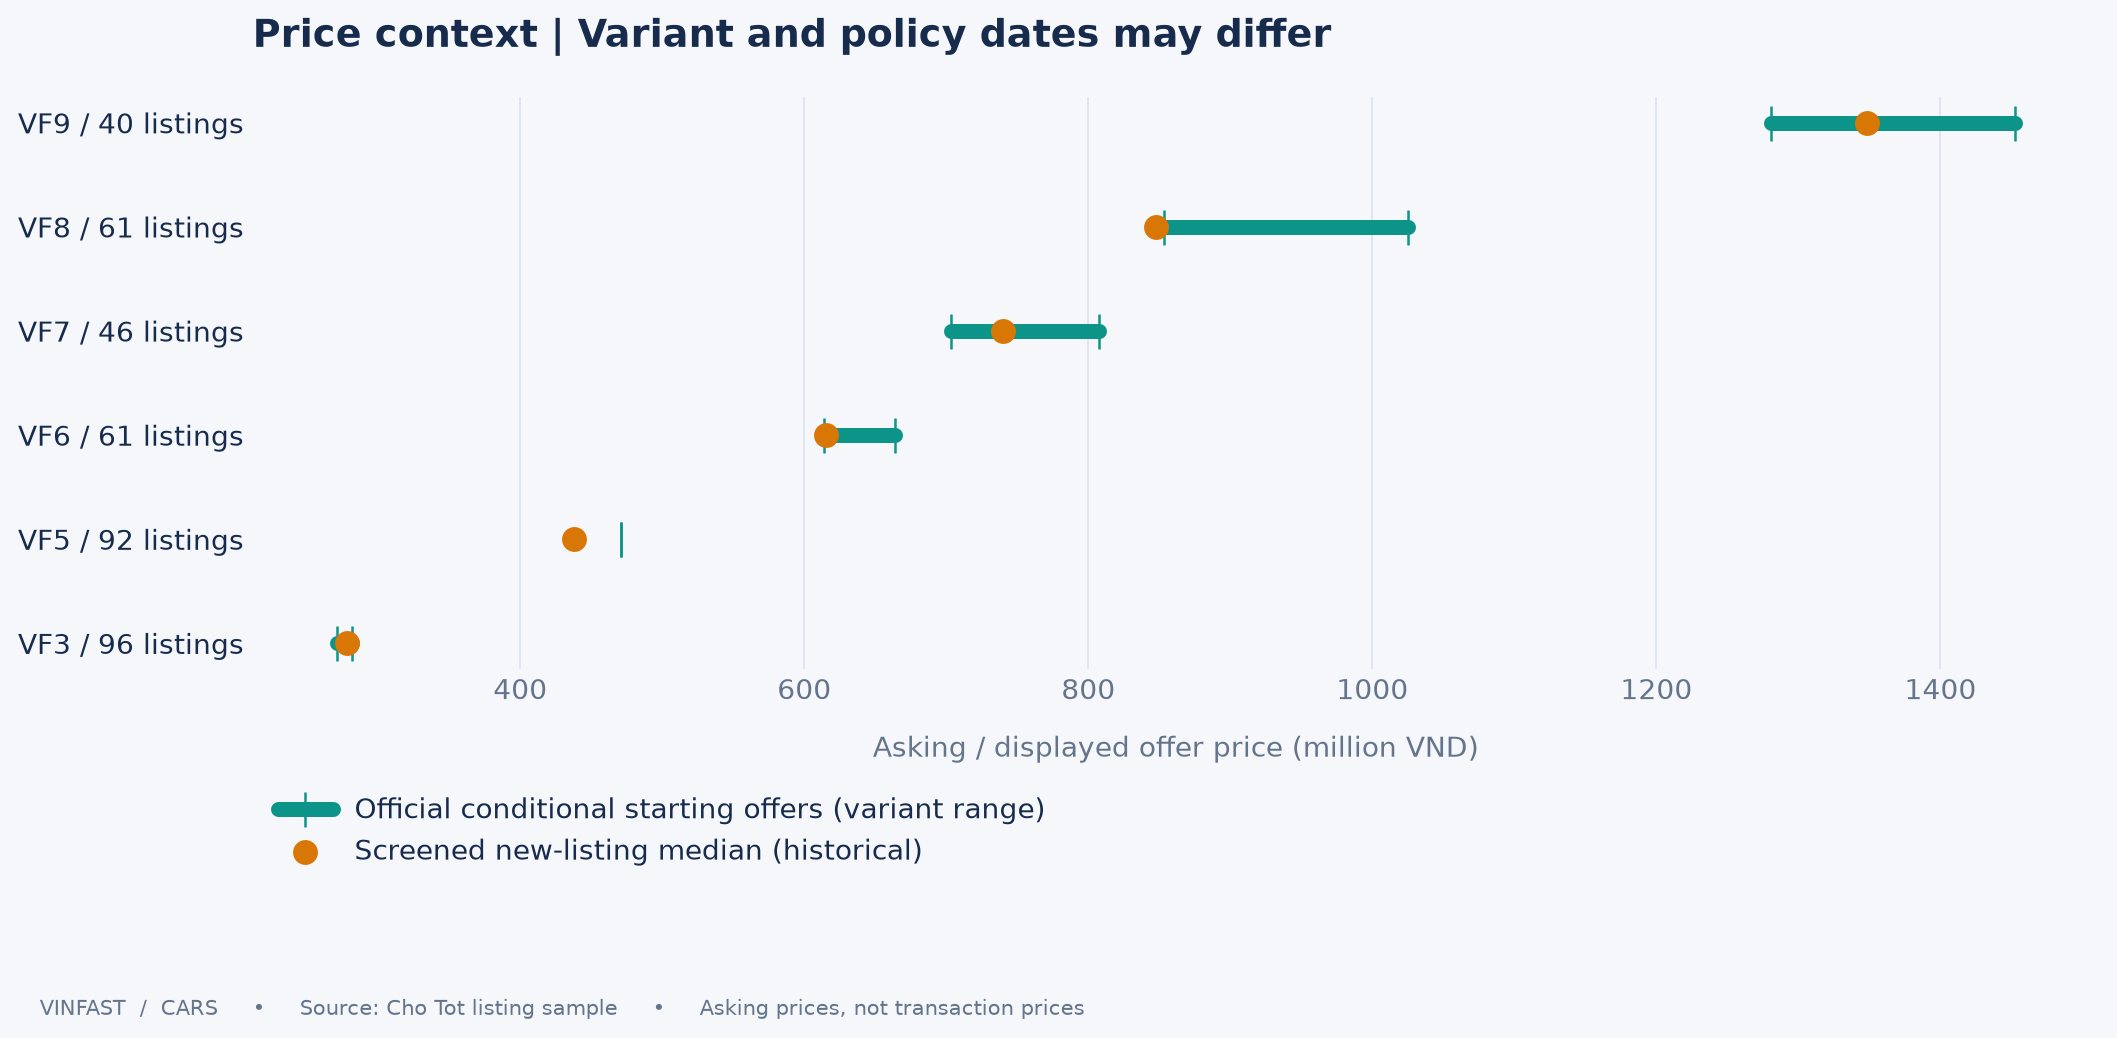

,official_offer_min_million_vnd,official_offer_max_million_vnd,historical_new_median_million_vnd,listing_count
family,,,,
VF3,270.75,281.20,278.0,96
VF5,471.20,471.20,438.0,92
VF6,613.70,664.05,615.0,61
VF7,703.00,807.50,740.0,46
VF8,853.10,1025.05,848.0,61
VF9,1280.60,1452.55,1348.0,40


**Cách dùng:** nếu báo giá cũ gần giá ưu đãi xe mới, cần xin báo giá cùng phiên bản và điều kiện pin trước khi quyết định. Không lấy chênh lệch trên đồ thị làm mức mặc cả tự động. Tham chiếu hãng được thu trực tiếp trong thư mục data/external, có SHA-256 và URL.

In [6]:
bench=refs.groupby('family').promo_vnd.agg(['min','max'])/1e6
market=clean[clean.condition=='New'].groupby('family').price_million.agg(['median','size'])
compare=bench.join(market).dropna()
fig,ax=plt.subplots(figsize=(12,6))
for i,(f,row) in enumerate(compare.iterrows()):
    ax.plot([row['min'],row['max']],[i,i],color=TEAL,lw=6,marker='|',markersize=14,solid_capstyle='round',label='Official conditional starting offers (variant range)' if i==0 else None)
    ax.scatter(row['median'],i,color=AMBER,s=80,zorder=3,label='Screened new-listing median (historical)' if i==0 else None)
ax.set_yticks(range(len(compare)),[f'{f} / {int(row["size"])} listings' for f,row in compare.iterrows()])
ax.set(title='Price context | Variant and policy dates may differ',xlabel='Asking / displayed offer price (million VND)')
ax.legend(loc='upper left',bbox_to_anchor=(0,-.18)); ax.grid(axis='x'); save(fig,'buyer_04_official_context')
display(compare.rename(columns={'min':'official_offer_min_million_vnd','max':'official_offer_max_million_vnd','median':'historical_new_median_million_vnd','size':'listing_count'}))
note('**Cách dùng:** nếu báo giá cũ gần giá ưu đãi xe mới, cần xin báo giá cùng phiên bản và điều kiện pin trước khi quyết định. Không lấy chênh lệch trên đồ thị làm mức mặc cả tự động. Tham chiếu hãng được thu trực tiếp trong thư mục data/external, có SHA-256 và URL.')

## F. Kết quả có bị quảng cáo lặp và ngưỡng làm sạch chi phối không?

Một người bán có thể có nhiều tin, kể cả nhiều tin cùng một xe. So sánh median toàn tin với
median của median từng người bán; cách thứ hai cho mỗi người bán trọng số bằng nhau,
**không phải khử trùng xe thực tế**. Đồng thời thay đổi ngưỡng giá thấp để xem kết quả nhạy đến đâu.

,listings,sellers,listing_median,seller_balanced_median,top_seller_share_pct
family,,,,,
EC VAN,24,22,248.00,248.00,12.50
Herio Green,6,6,378.00,378.00,16.67
Limo Green,114,79,641.84,630.00,7.89
MPV7,31,30,692.00,692.50,6.45
Minio Green,9,9,184.00,184.00,11.11
Nerio Green,1,1,450.00,450.00,100.00
VF2,27,27,180.00,180.00,3.70
VF3,168,114,270.00,266.25,5.95
VF5,135,105,430.00,420.00,7.41


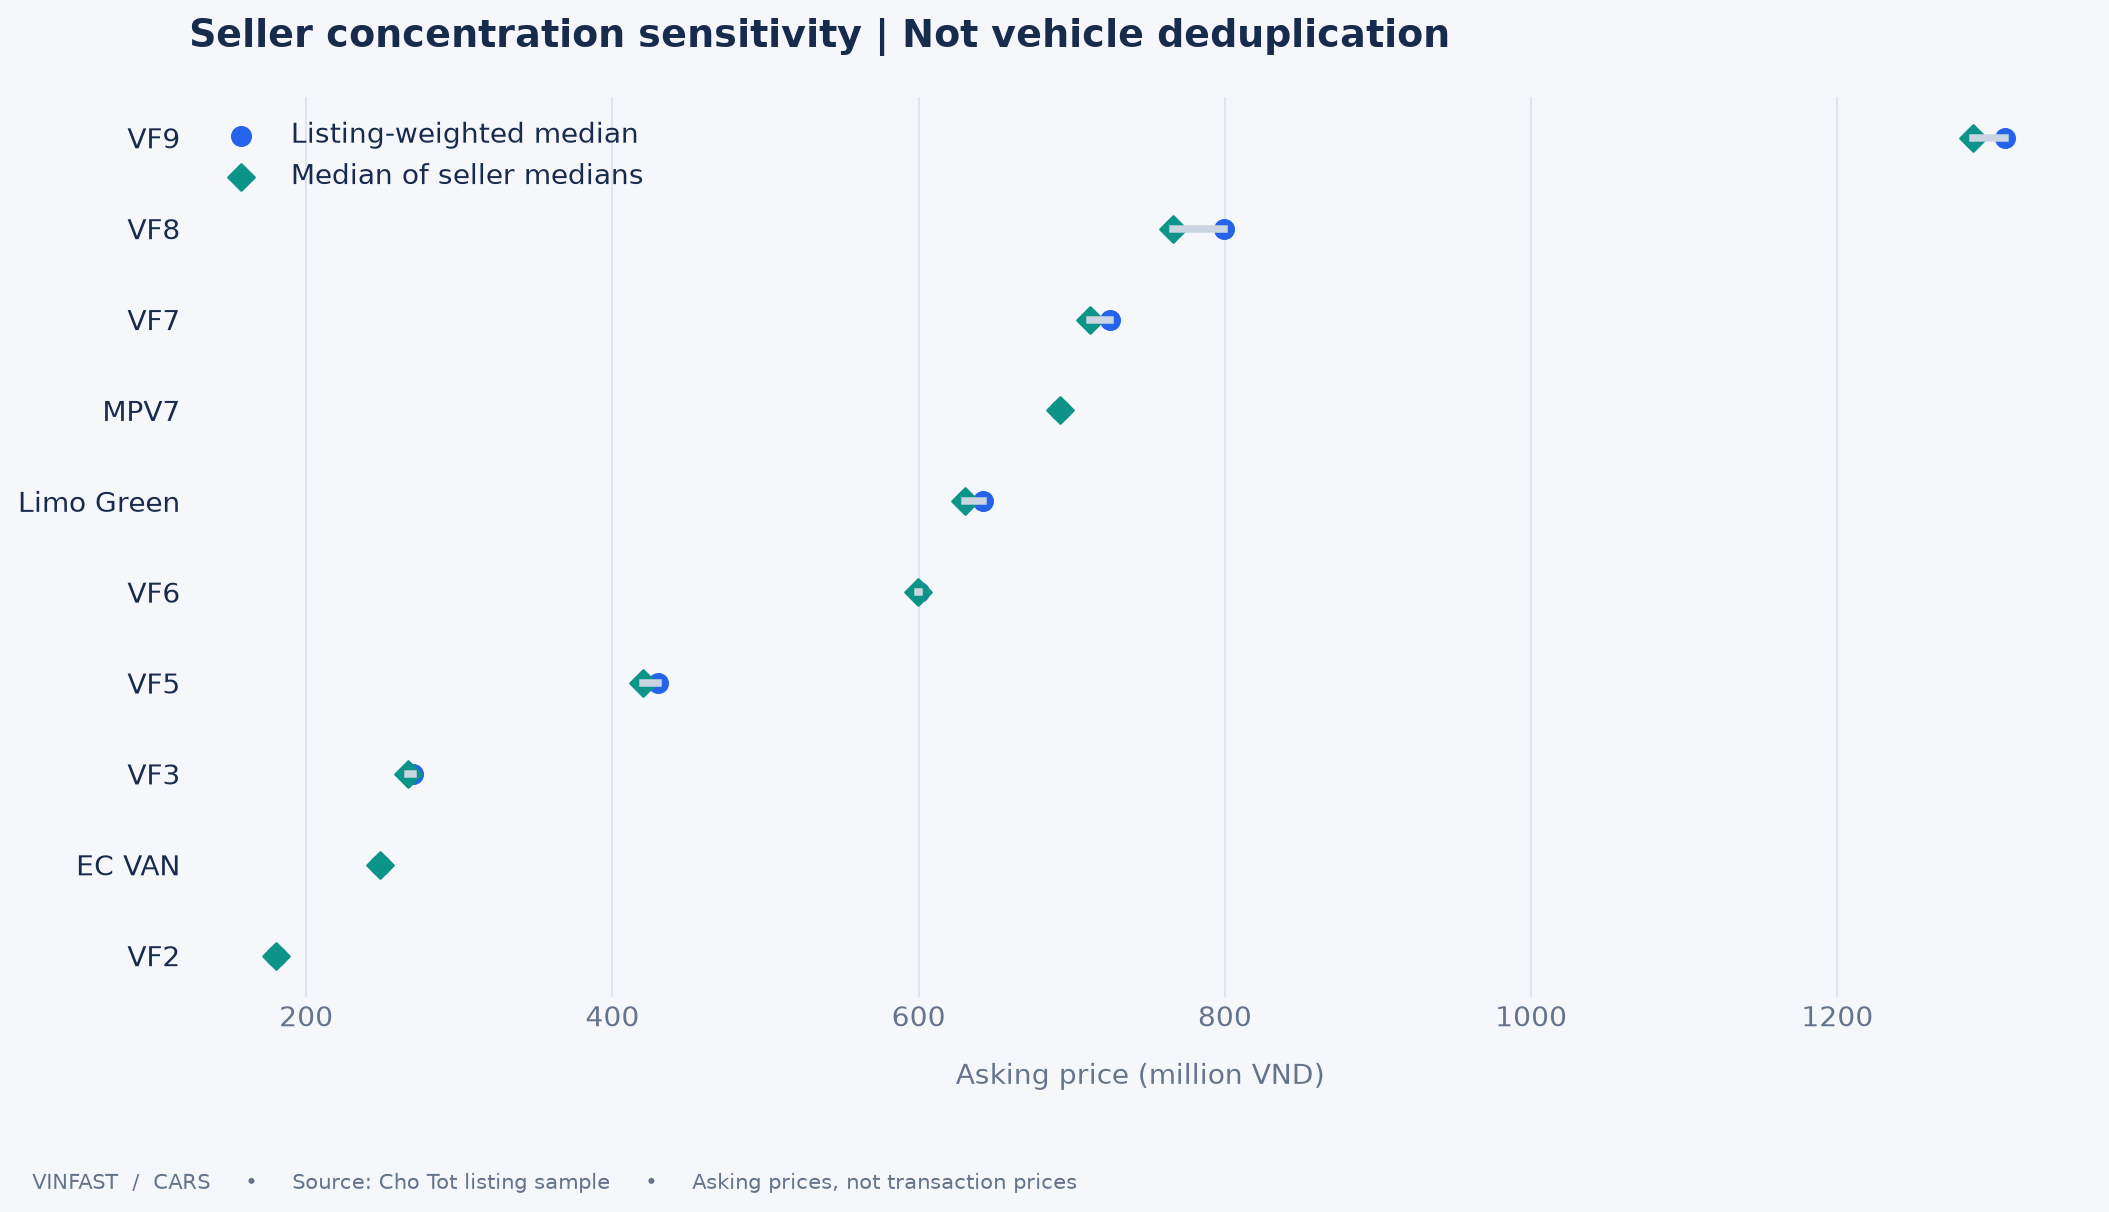

floor_million_vnd,50,100,150
family,,,
EC VAN,248.00,248.00,248.00
Herio Green,378.00,378.00,378.00
Limo Green,640.00,641.84,641.84
MPV7,692.00,692.00,692.00
Minio Green,184.00,184.00,186.00
Nerio Green,450.00,450.00,450.00
VF2,180.00,180.00,180.00
VF3,269.50,270.00,270.00
VF5,429.13,430.00,430.00


**Cách đọc:** model có ít người bán hoặc median thay đổi rõ khi cân bằng người bán cần đọc tin kỹ hơn. Median ổn định qua ngưỡng chỉ là một kiểm tra độ nhạy, không chứng minh giá đã sạch hoặc mẫu đại diện.

In [7]:
seller=clean.groupby('family').agg(listings=('list_id','size'),sellers=('seller_key','nunique'),listing_median=('price_million','median'))
seller['seller_balanced_median']=clean.groupby(['family','seller_key']).price_million.median().groupby('family').median()
seller['top_seller_share_pct']=clean.groupby('family').seller_key.apply(lambda s:s.value_counts().iloc[0]/len(s)*100)
display(seller.round(2))
g=seller[seller.listings>=10].sort_values('listing_median')
fig,ax=plt.subplots(figsize=(12,7))
for i,row in enumerate(g.itertuples()):
    ax.plot([row.listing_median,row.seller_balanced_median],[i,i],color='#CBD5E1',lw=3)
ax.scatter(g.listing_median,range(len(g)),color=BLUE,label='Listing-weighted median',s=55)
ax.scatter(g.seller_balanced_median,range(len(g)),color=TEAL,label='Median of seller medians',s=55,marker='D')
ax.set_yticks(range(len(g)),g.index); ax.set(title='Seller concentration sensitivity | Not vehicle deduplication',xlabel='Asking price (million VND)'); ax.grid(axis='x'); ax.legend(); save(fig,'buyer_05_seller_sensitivity')
sens=[]
for floor in [50,100,150]:
    s=historical[historical.scope_eligible & historical.price_million.ge(floor) & ~historical.upfront_price_match]
    for f,g in s.groupby('family'):
        sens.append({'family':f,'floor_million_vnd':floor,'listings':len(g),'median_million_vnd':g.price_million.median()})
sens=pd.DataFrame(sens); display(sens.pivot(index='family',columns='floor_million_vnd',values='median_million_vnd').round(2))
note('**Cách đọc:** model có ít người bán hoặc median thay đổi rõ khi cân bằng người bán cần đọc tin kỹ hơn. Median ổn định qua ngưỡng chỉ là một kiểm tra độ nhạy, không chứng minh giá đã sạch hoặc mẫu đại diện.')

## G. Quảng cáo tài chính và pin: thông tin nào cần hỏi trước khi đặt cọc?

Tần suất từ khóa chỉ là mức độ nhắc đến. Không suy nhu cầu, không gán sentiment.
Tách các nhóm không nhắc, nhắc mua pin, nhắc thuê pin, nhắc cả hai; không mặc định “không nhắc” = kèm pin.
Người mua nên yêu cầu báo giá toàn xe, điều kiện ưu đãi, hợp đồng pin và nghĩa vụ còn lại.

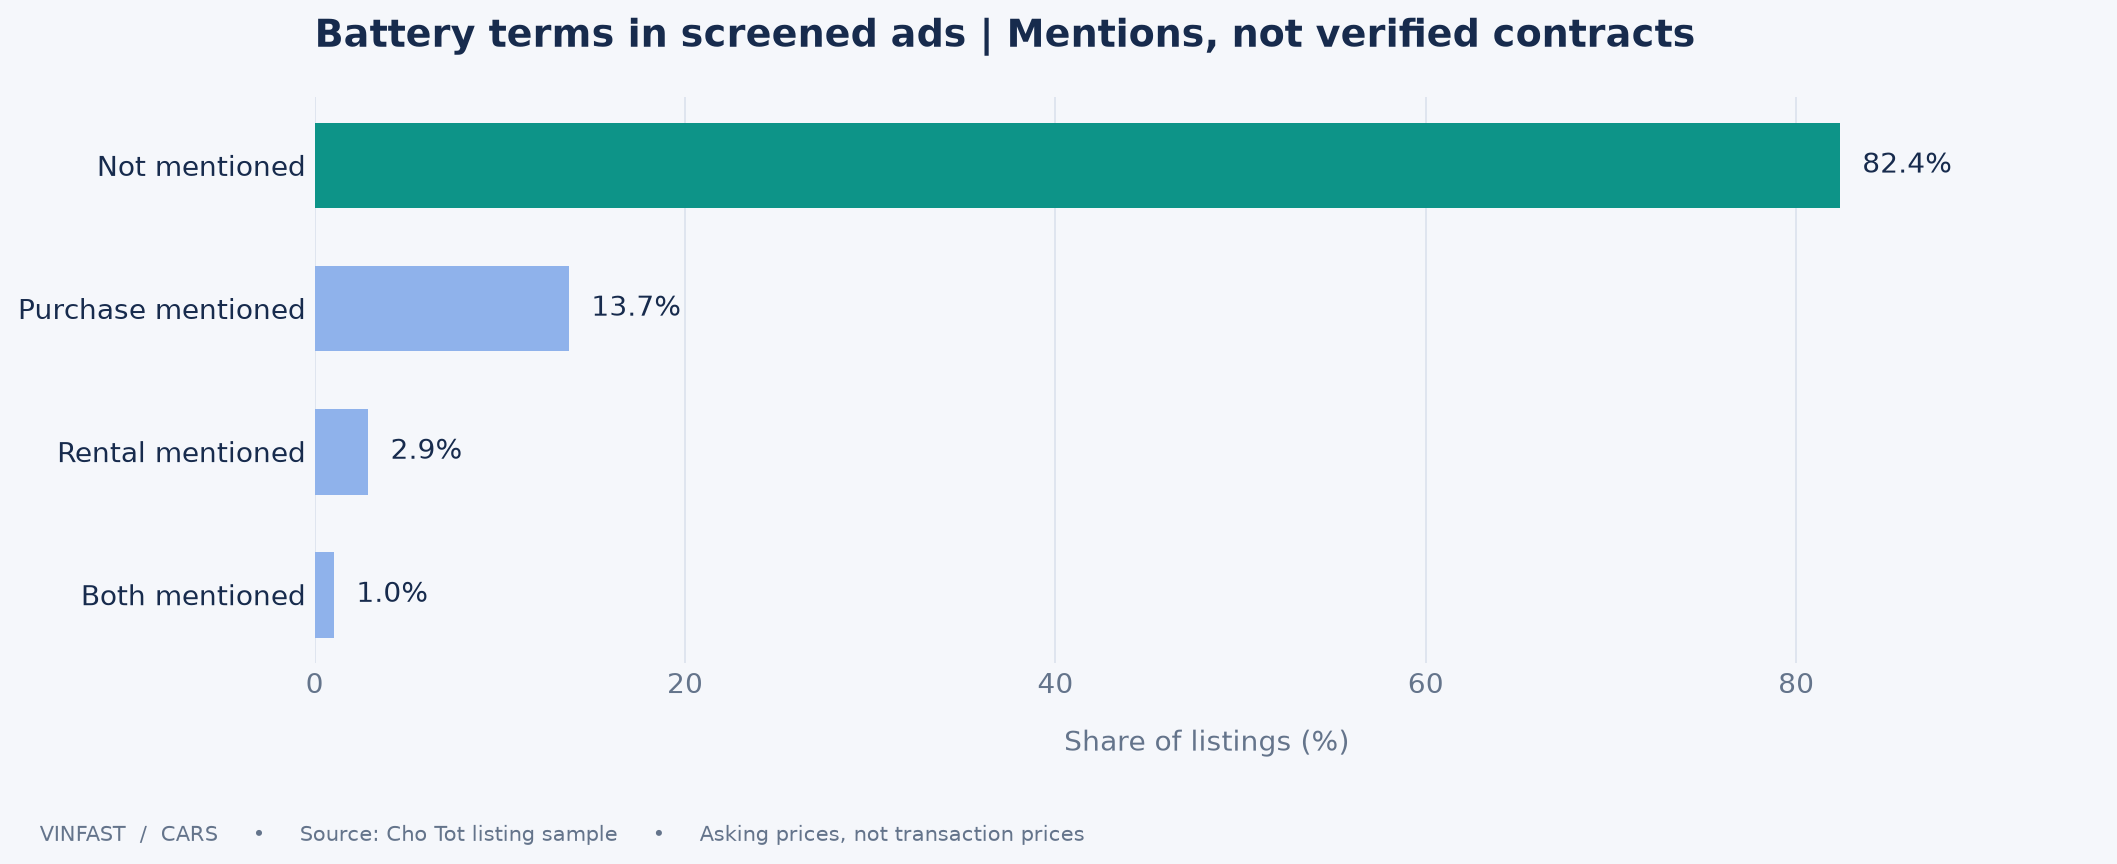

,listings,financing_pct,promo_pct
family,,,
EC VAN,24,54.17,91.67
Herio Green,6,33.33,50.00
Limo Green,114,63.16,70.18
MPV7,31,58.06,80.65
Minio Green,9,55.56,55.56
Nerio Green,1,0.00,0.00
VF2,27,33.33,51.85
VF3,168,33.93,37.50
VF5,135,49.63,47.41


,list_id,family,condition,year,price_vnd,battery_topic,financing_mention,subject
411,134576978,VF3,Used,2024,235000000,Rental mentioned,False,Vinfast VF3 2024 Hồng 3.668km Điện
478,134555046,VF3,Used,2025,265000000,Not mentioned,False,𝐕𝐢𝐧𝐅𝐚𝐬𝐭 𝐕𝐅𝟑 𝟐𝟎𝟐𝟓 𝐗𝐚́𝐦 𝟒.𝟎𝟎𝟎 𝐤𝐦-𝐍𝐇𝐈𝐄̂̀𝐔 𝐏𝐊 𝐗𝐈̣𝐍
78,134629241,VF6,Used,2025,470000000,Not mentioned,False,VinFast VF6 2025 Đen 140.000 km
895,134345624,VF3,Used,2025,300000000,Not mentioned,False,VinFast VF3 TC1 Xám
449,134327262,VF8,Used,2025,850000000,Purchase mentioned,True,Thanh lý VinFast VF 8 Plus 2025 Trắng Mỹ 20.000KM
686,131319998,VF5,New,2025,440000000,Not mentioned,True,VF5 PLUS TRẢ TRƯỚC TỪ 50tr NHẬN XE
975,134258426,Minio Green,Used,2026,168000000,Not mentioned,False,VinFast MiniO Green Trắng lăn bánh
685,132494349,VF8,New,2026,750000000,Not mentioned,True,VINFAST VF8 NEW SẴN XE ĐỂ XEM SỜ TẬN TAY
23,133426049,Limo Green,New,2026,630000000,Not mentioned,False,DEAL SỐC THÁNG 9 LIMO GREEN - TẶNG FILM CAM SÀN
933,134312809,VF8,Used,2022,640000000,Purchase mentioned,True,VinFast VF8 Plus 2022 Full ADAS - Đi ít odo 5v


**Checklist khi liên hệ:** 1) số tiền thanh toán toàn xe và phí ngoài giá; 2) phiên bản và năm/VIN; 3) pin mua hay thuê, công nợ và chuyển nhượng; 4) SOH/kiểm tra pin; 5) bảo hành theo VIN/ngày kích hoạt; 6) lịch sử tai nạn, ngập nước, bảo dưỡng. Chưa có các dữ liệu này nên project không chứng nhận tin nào đáng mua.

In [8]:
topic=clean.battery_topic.value_counts()
barh(topic/len(clean)*100,'Battery terms in screened ads | Mentions, not verified contracts','Share of listings (%)','buyer_06_battery_terms',TEAL)
display(clean.groupby('family').agg(listings=('list_id','size'),financing_pct=('financing_mention',lambda s:s.mean()*100),promo_pct=('promo_mention',lambda s:s.mean()*100)).round(2))
review=clean[['list_id','family','condition','year','price_vnd','battery_topic','financing_mention','subject']].sample(min(15,len(clean)),random_state=42)
display(review)
note('**Checklist khi liên hệ:** 1) số tiền thanh toán toàn xe và phí ngoài giá; 2) phiên bản và năm/VIN; 3) pin mua hay thuê, công nợ và chuyển nhượng; 4) SOH/kiểm tra pin; 5) bảo hành theo VIN/ngày kích hoạt; 6) lịch sử tai nạn, ngập nước, bảo dưỡng. Chưa có các dữ liệu này nên project không chứng nhận tin nào đáng mua.')

## H. Chi phí sử dụng: mô hình kịch bản minh bạch

Trang VF5 công bố **13 kWh/100 km**. Dùng riêng thông số này, không suy từ dung lượng pin/chạy xa.
Giả định kịch bản có thể sửa: mức tiêu hao thực tế bằng 1,25 lần công bố; hiệu suất sạc 90%;
đơn giá điện 3.000 hoặc 4.000 VND/kWh; đối chứng xe xăng **giả định** 6,5 L/100 km và
23.000 VND/L. Đây không phải báo giá điện/xăng hiện hành hay thông số một xe xăng cụ thể.
Kịch bản sạc miễn phí chỉ áp dụng khi người mua tự xác nhận đủ điều kiện; không mặc định cho tất cả.

Đây là **chi phí năng lượng**, chưa phải TCO. TCO còn giá mua trừ bán lại, lãi vay, bảo hiểm,
phí, bảo dưỡng, sửa chữa, sạc nhà và pin. Không đưa ra kết luận “EV rẻ hơn tổng thể”.

,Scenario input (units in field names)
vf5_published_kwh_per_100km,13.00
real_world_multiplier,1.25
charging_efficiency,0.90
ice_l_per_100km_assumed,6.50
petrol_vnd_per_l_assumed,23000.00
battery_rental_vnd_month_assumed,0.00


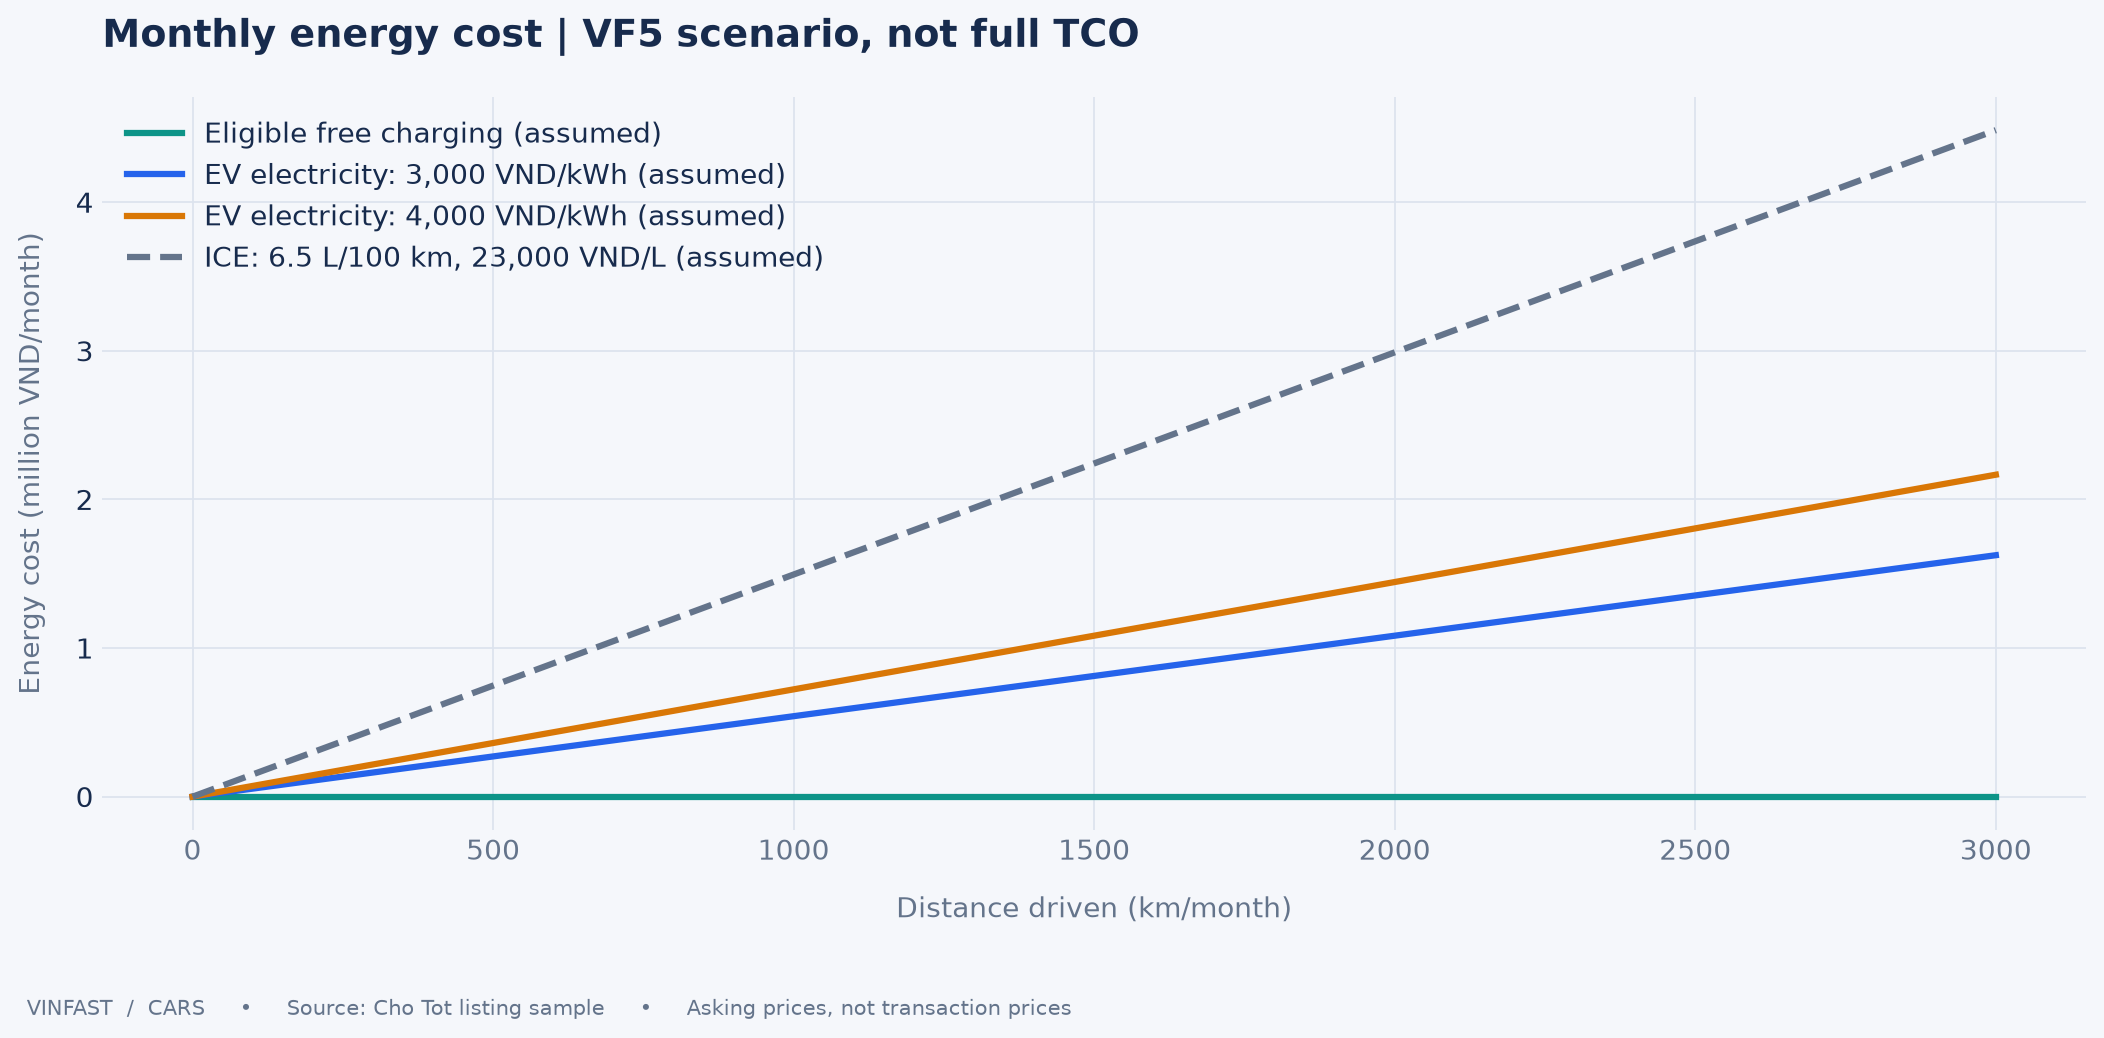

,electricity_vnd_per_kwh_assumed,cost_at_1500km_vnd_month
0,0,0.000000e+00
1,3000,8.125000e+05
2,4000,1.083333e+06


**Diễn giải:** đường chi phí thay đổi theo quãng đường và đơn giá. Lợi thế năng lượng không tự bù được chênh lệch giá mua/lãi vay/giá bán lại. Khi có thuê pin, nhập phí thực vào biến; không dùng 0 cho xe đang thuê pin. Nếu sạc nhà khó khăn, cần đánh giá thời gian và tuyến sạc ngoài mô hình này.

In [9]:
vf5text=(REFDIR/'VF5.txt').read_text(encoding='utf-8'); assert '13 kWh/100 km' in vf5text
assumptions={'vf5_published_kwh_per_100km':13,'real_world_multiplier':1.25,'charging_efficiency':.90,
             'ice_l_per_100km_assumed':6.5,'petrol_vnd_per_l_assumed':23000,'battery_rental_vnd_month_assumed':0}
display(pd.Series(assumptions,name='Scenario input (units in field names)').to_frame())
distance=np.arange(0,3001,100)
fig,ax=plt.subplots(figsize=(12,6))
scenario_rows=[]
for tariff,color in [(0,TEAL),(3000,BLUE),(4000,AMBER)]:
    cost=distance/100*13*1.25/.9*tariff+assumptions['battery_rental_vnd_month_assumed']
    label='Eligible free charging (assumed)' if tariff==0 else f'EV electricity: {tariff:,} VND/kWh (assumed)'
    ax.plot(distance,cost/1e6,label=label,color=color,lw=2.5)
    scenario_rows.append({'electricity_vnd_per_kwh_assumed':tariff,'cost_at_1500km_vnd_month':1500/100*13*1.25/.9*tariff})
ice=distance/100*6.5*23000
ax.plot(distance,ice/1e6,color=MUTED,ls='--',lw=2.5,label='ICE: 6.5 L/100 km, 23,000 VND/L (assumed)')
ax.set(title='Monthly energy cost | VF5 scenario, not full TCO',xlabel='Distance driven (km/month)',ylabel='Energy cost (million VND/month)'); ax.grid(); ax.legend(); save(fig,'buyer_07_energy_scenario')
display(pd.DataFrame(scenario_rows)); note('**Diễn giải:** đường chi phí thay đổi theo quãng đường và đơn giá. Lợi thế năng lượng không tự bù được chênh lệch giá mua/lãi vay/giá bán lại. Khi có thuê pin, nhập phí thực vào biến; không dùng 0 cho xe đang thuê pin. Nếu sạc nhà khó khăn, cần đánh giá thời gian và tuyến sạc ngoài mô hình này.')

## I. Tin nào có thể đưa vào danh sách liên hệ?

Xuất bảng ứng viên từ nhóm **cùng family–condition–year–region** có ít nhất 10 tin và 3 người bán.
Gắn vị trí dưới P25/trong P25–P75/trên P75, không đặt nhãn “hời”. Chỉ đưa listing vào nhóm
so sánh khi đã qua sàng lọc; chưa có phiên bản, SOH, pin hay xác nhận xe còn bán.
Không xuất số điện thoại hoặc thông tin tài khoản cá nhân trong bảng ứng viên.

In [10]:
keys=['family','condition','year','region']
peer=clean.groupby(keys).agg(peer_listings=('list_id','size'),peer_sellers=('seller_key','nunique'),peer_median_vnd=('price_vnd','median'),peer_p25_vnd=('price_vnd',lambda s:s.quantile(.25)),peer_p75_vnd=('price_vnd',lambda s:s.quantile(.75)))
candidates=clean.merge(peer.reset_index(),on=keys,validate='many_to_one')
candidates=candidates[(candidates.peer_listings>=10)&(candidates.peer_sellers>=3)].copy()
candidates['price_position']=np.select([candidates.price_vnd<candidates.peer_p25_vnd,candidates.price_vnd>candidates.peer_p75_vnd],['Below peer P25: verify','Above peer P75: check extras'],default='Within peer IQR')
candidates['verification_status']='Unverified historical ad; confirm availability, trim, battery and full price'
candidates=candidates[['list_id','family','condition','year','region','price_vnd','odo_km','battery_topic','peer_listings','peer_sellers','peer_median_vnd','peer_p25_vnd','peer_p75_vnd','price_position','verification_status','subject']]
candidates.to_csv(OUT/'buyer_comparison_candidates.csv',index=False,encoding='utf-8-sig')
display(candidates.head(15))
note(f'**Kết quả sử dụng:** {len(candidates)} tin lịch sử có nhóm so sánh đủ hỗ trợ theo ngưỡng này. Đây là bảng phục vụ đọc/đối chiếu, không phải danh sách xe còn bán đã xác minh. Đổi ngân sách, mới/cũ và vùng trong pandas để lọc theo người mua cụ thể.')
# Fresh cohort remains a separate validation slice.
display(recent.groupby(['family','condition']).agg(listings=('list_id','size'),price_screened=('price_eligible','sum')))
assert all(hashlib.sha256(Path(p).read_bytes()).hexdigest()==h for p,h in hashes.items())
assert len(refs)==12 and all(p.stat().st_size>1000 for p in saved)
note(f'**Kiểm tra:** {len(saved)} hình mới; {len(refs)} cấu hình giá tham chiếu; nguồn cũ giữ nguyên hash; ID không trùng trong từng cohort. Chưa có theo dõi đã bán hay dữ liệu giao dịch; không suy growth/DOM/nhu cầu từ mẫu này.')

,list_id,family,condition,year,region,price_vnd,odo_km,battery_topic,peer_listings,peer_sellers,peer_median_vnd,peer_p25_vnd,peer_p75_vnd,price_position,verification_status,subject
1,134518548,VF3,New,2026,Ho Chi Minh City,278000000,NaN,Not mentioned,68,40,278000000.0,276750000.0,278000000.0,Within peer IQR,Unverified historical ad; confirm availability...,"VinFast VF3 Eco, Plus Điện đủ mẫu mã giá sập sàn🚨"
3,134609331,VF3,Used,2024,Ho Chi Minh City,195000000,28000.0,Rental mentioned,14,14,202000000.0,198000000.0,218000000.0,Below peer P25: verify,Unverified historical ad; confirm availability...,VinFast VF3 2024 Vàng Điện
4,134331029,VF3,New,2026,Ho Chi Minh City,266000000,NaN,Not mentioned,68,40,278000000.0,276750000.0,278000000.0,Below peer P25: verify,Unverified historical ad; confirm availability...,VinFast VF 3 PLUS Đỏ SẴN XE GIAO NGAY TRẢ TRƯỚ...
6,134608049,Limo Green,New,2026,Ho Chi Minh City,649000000,NaN,Not mentioned,64,43,652000000.0,629750000.0,664000000.0,Within peer IQR,Unverified historical ad; confirm availability...,"VinFast LimoGreen, trả trước 84tr, nhận xe ngay"
13,133679636,MPV7,New,2026,Ho Chi Minh City,705000000,NaN,Not mentioned,23,22,699000000.0,650000000.0,710000000.0,Within peer IQR,Unverified historical ad; confirm availability...,VinFast VF MPV 7 Trả Trước 100tr
15,133840245,VF5,New,2026,Ho Chi Minh City,425000000,NaN,Not mentioned,66,40,446000000.0,431000000.0,471000000.0,Below peer P25: verify,Unverified historical ad; confirm availability...,VinFast VF5 Plus mới đủ màu đủ mẫu-Giá sập sàn
16,134284878,VF5,New,2026,Ho Chi Minh City,430000000,NaN,Not mentioned,66,40,446000000.0,431000000.0,471000000.0,Below peer P25: verify,Unverified historical ad; confirm availability...,"VF5 vay 85-100%, giảm giá 66t, còn 430t"
20,134564899,VF5,New,2026,Ho Chi Minh City,444000000,NaN,Not mentioned,66,40,446000000.0,431000000.0,471000000.0,Within peer IQR,Unverified historical ad; confirm availability...,VINFAST VF5 PLUS - 444 TRIỆU - CHƯƠNG TRÌNH TH...
21,134611629,VF5,New,2026,Ho Chi Minh City,471000000,NaN,Not mentioned,66,40,446000000.0,431000000.0,471000000.0,Within peer IQR,Unverified historical ad; confirm availability...,VF5 HỖ TRỢ VAY ĐẾN 90%-BAO HỒ SƠ XẤU
22,133839004,VF3,New,2026,Ho Chi Minh City,280000000,NaN,Not mentioned,68,40,278000000.0,276750000.0,278000000.0,Above peer P75: check extras,Unverified historical ad; confirm availability...,VinFast VF3 Trắng


**Kết quả sử dụng:** 528 tin lịch sử có nhóm so sánh đủ hỗ trợ theo ngưỡng này. Đây là bảng phục vụ đọc/đối chiếu, không phải danh sách xe còn bán đã xác minh. Đổi ngân sách, mới/cũ và vùng trong pandas để lọc theo người mua cụ thể.

listings  price_screened
family     condition                          
Dòng khác  New               1               0
EC VAN     New               1               1
Limo Green New               7               7
MPV7       New               3               3
VF2        New               3               3
VF3        New               3               3
           Used              9               9
VF5        New               8               7
           Used              1               1
VF6        New               4               4
           Used              2               2
VF7        New               1               1
           Used              2               2
VF8        New               3               3
           Used              1               1
VF9        New               1               1

**Kiểm tra:** 8 hình mới; 12 cấu hình giá tham chiếu; nguồn cũ giữ nguyên hash; ID không trùng trong từng cohort. Chưa có theo dõi đã bán hay dữ liệu giao dịch; không suy growth/DOM/nhu cầu từ mẫu này.

## Đọc kết quả và phần còn thiếu

Kết quả đã phục vụ các quyết định: shortlist theo ngân sách, mức chào bán thường gặp,
chênh mới/cũ trong nhóm có hỗ trợ, ảnh hưởng người bán, câu hỏi cần hỏi về pin và chi phí năng lượng.
Phần tiếp theo cần dữ liệu mới thực sự: lịch sử snapshot ổn định, phiên bản và giá toàn xe được gán nhãn,
trạng thái bán, hợp đồng pin/SOH, điều kiện bảo hành theo VIN và vị trí sạc có kiểm chứng.
Không dùng một chỉ số “hot” để thay tất cả quyết định của khách hàng.

Nguồn tham chiếu công khai: [VF3](https://shop.vinfastauto.com/vn_vi/dat-coc-xe-dien-vf3.html),
[VF5](https://shop.vinfastauto.com/vn_vi/dat-coc-xe-dien-vf5.html),
[VF6](https://shop.vinfastauto.com/vn_vi/dat-coc-xe-dien-vf6.html),
[VF7](https://shop.vinfastauto.com/vn_vi/dat-coc-xe-dien-vf7.html),
[VF8](https://shop.vinfastauto.com/vn_vi/dat-coc-xe-vf8.html),
[VF9](https://shop.vinfastauto.com/vn_vi/dat-coc-xe-vf9.html).
Chính sách bảo hành chưa tải được bản cục bộ (HTTP 403); không gán bảo hành còn lại từ model/năm xe.
Trang otodien được lưu để kiểm tra cấu trúc, chưa trích listing vào cohort do chưa kiểm chứng ID/model.